#Исследовательский анализ датасета после переработки

##Загрузка библиотек и написание собственных функций

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', module='pandas')
warnings.simplefilter(action='ignore', category=FutureWarning)

#ограничение вывода экспонинцеального вывода чисел
np.set_printoptions(suppress=True)

In [2]:
pip install --upgrade gdown

In [3]:
#функция для изучения данных на аномальные значения и попуски
#функция принимает на вход DataFrame, выводит текстовые сообщения на консоль
def anomaly(data):
  #сли передан Series, преобразуем его в DataFrame
  if isinstance(data, pd.Series):
    data = data.to_frame()
  #выводим размер датасета
  print(f'Размер файла:{data.shape}')
  print('-'*100)
  #для вывода всех столбцов создаем цикл
  #выделяем в отдельную переменную названия столбцов
  column_data= data.columns
  #циклом перебираем все значения и выводим данные
  for c in column_data:
    #выводим все уникальные значения
    print(f'Уникальные значения показателя: {c}')
    print(data[c].unique())
    #считаем количество уникальных значений
    print(f'Количество уникальных значений: {data[c].nunique()}')
    #считаем количество всех значений
    print(f'Количество всех значений: {data[c].count()}')
    #считаем количество пропусков
    print(f'Количество пропусков в столбце {c}: {data[c].isna().sum()}')
    print('-'*100)

In [4]:
#функция для исследовательского анализа количественных данных
#функция принимает на вход DataFrame (количественные данные), выводит графики на консоль
def analisys_num(data):
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    #настраиваем построение гистограммы
    axes[0].hist(data.dropna(), bins=20)
    axes[0].set_title('Гистограмма показателя')
    axes[0].set_xlabel('Значения показателя')
    #визуально выводим среднее значение и медиану
    axes[0].axvline(data.median(), color='b', linestyle='dashed', linewidth=2)
    axes[0].axvline(data.mean(), color='r', linestyle='solid', linewidth=2)
    axes[0].legend(['Медиана', 'Среднее', 'Мода'], prop={'size': 6})

    #постройка боксплота для данных
    axes[1].set_title('Боксплот показателя')
    axes[1].boxplot(data.dropna())
    #настройка скрипичной диаграммы
    axes[2].set_title('Скрипичная диаграмма показателя')
    axes[2].violinplot([data.dropna()], vert=False, widths=0.75,
                       showmeans=True, showmedians=True)
    plt.tight_layout()
    plt.show()
    #выводим статистику по показателю
    print('Показатели описательной статистики')
    print(data.describe())
    print(f'Мода в данных по показателю: {data.mode()}')

In [5]:
#функция для исследовательского анализа качественных данных с использованием круговой диаграммы
#функция принимает данные и считает их количество внутри каждого уникального значения,
#после выводит круговой график
#функция принимает на вход DataFrame, выводит графики на консоль
def analisys_cat_pie(data, labels=None):
    if labels is not None:
      data = data.map(labels)

    data.value_counts().plot(kind='pie', autopct='%.2f%%', figsize=(5, 5))
    plt.title('Круговая диаграмма показателя', size=10)
    plt.show()

In [6]:
#функция для исследовательского анализа качевтенных данных с использованием столбчатой диаграммы
#функция принимает данные и считает их количество внутри каждого уникального значения,
#после выводит столбчатую диаграмму
#функция принимает на вход DataFrame, выводит графики на консоль
def analisys_cat_plot(data):
    data.value_counts(ascending=True).plot(kind='bar', alpha=0.8)
    plt.title('Столбчатая диаграмма', size=15)
    plt.xlabel('Количество', size=12)
    plt.ylabel('Значения', size=12)
    plt.show()

In [7]:
#функция для вывода графика Lmplot
#функция принимает датасет и названия столбцов, по которым надо построить график
#функция принимает на вход DataFrame, выводит графики сообщения на консоль
def grafic(data, x, y):
    sns.lmplot(x=x, y=y, data=data)
    plt.title(f'Зависимость показателя {y} от показателя {x}', size=10)
    plt.xlabel(f'Показатель {x}', size=8)
    plt.ylabel(f'Показатель {y}', size=8)
    plt.show()

In [8]:
#функция для изучения распределния показателя в группах по целевому признаку
#функция принимает числовые данные для каждой группы и строит боксплот
def target_sigh(data, target_col, sign_col):
  sns.boxplot(x=target_col, y=sign_col, data=data)
  plt.title(f'Сравнение показателя {sign_col} у пациентов')
  plt.xlabel('Показатель')
  plt.show()

In [9]:
#функция для изучения распределения категориального фактора внутри группы целевого признака
#функция принимает количество категориальых данных в группе и строит гистограмму
def target_group(data, target_col, sign_col):
  plot_grouped_data(data, group_cols=[target_col, sign_col],
      rename_dict={
          'index': {0: 'Нет', 1: 'Есть'}
      }
  )
  plt.show()

##Первичная оценка данных

In [10]:
! gdown 1yDnnOgqq9gsr0jIvjCg2Y3pLKoLIBK9u

Downloading...
From: https://drive.google.com/uc?id=1yDnnOgqq9gsr0jIvjCg2Y3pLKoLIBK9u
To: /content/etalon_df.csv
100% 722k/722k [00:00<00:00, 79.5MB/s]


In [11]:
df = pd.read_csv('/content/etalon_df.csv')

In [12]:
df.head(2)

,Unnamed: 0,study_ID,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo
0,0,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,0,87,2.21,84.0,26.3,119.1,320.0,21.300000,52.144544,36.245919,1.140000,0.0,0.0,0.0,0.0,0.0,10.0,6.500000,1.300000,1.500000,0.200000,0.000000,3.000000,67.000000,0.294582,0.0,100.000000,7.579015,16.438954,0.0,12.000000,1.0,2.0,0.0,0.0,0.0,0.0,0.0
1,1,05deb1af-cf40-11e9-80ba-901b0e633689_result_1803,0,87,1.91,74.0,23.6,123.8,315.0,12.280473,41.106126,33.459317,0.903516,0.0,0.0,0.0,0.0,0.0,9.1,5.267876,4.590942,0.514909,0.416559,0.037165,4.772653,59.783114,0.508563,0.0,219.848188,7.908197,16.905172,0.0,3.174857,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
anomaly(df)

Размер файла:(1924, 40)
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: Unnamed: 0
[   0    1    2 ... 3112 3113 3114]
Количество уникальных значений: 1924
Количество всех значений: 1924
Количество пропусков в столбце Unnamed: 0: 0
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: study_ID
['05deb1af-cf40-11e9-80ba-901b0e633689_result_1802'
 '05deb1af-cf40-11e9-80ba-901b0e633689_result_1803'
 '05deb1af-cf40-11e9-80ba-901b0e633689_result_1805' ...
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2593'
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2594'
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2595']
Количество уникальных значений: 1924
Количество всех значений: 1924
Количество пропусков в столбце study_ID: 0
----------------------------------------------------------------------------------------------------
Уникальные з

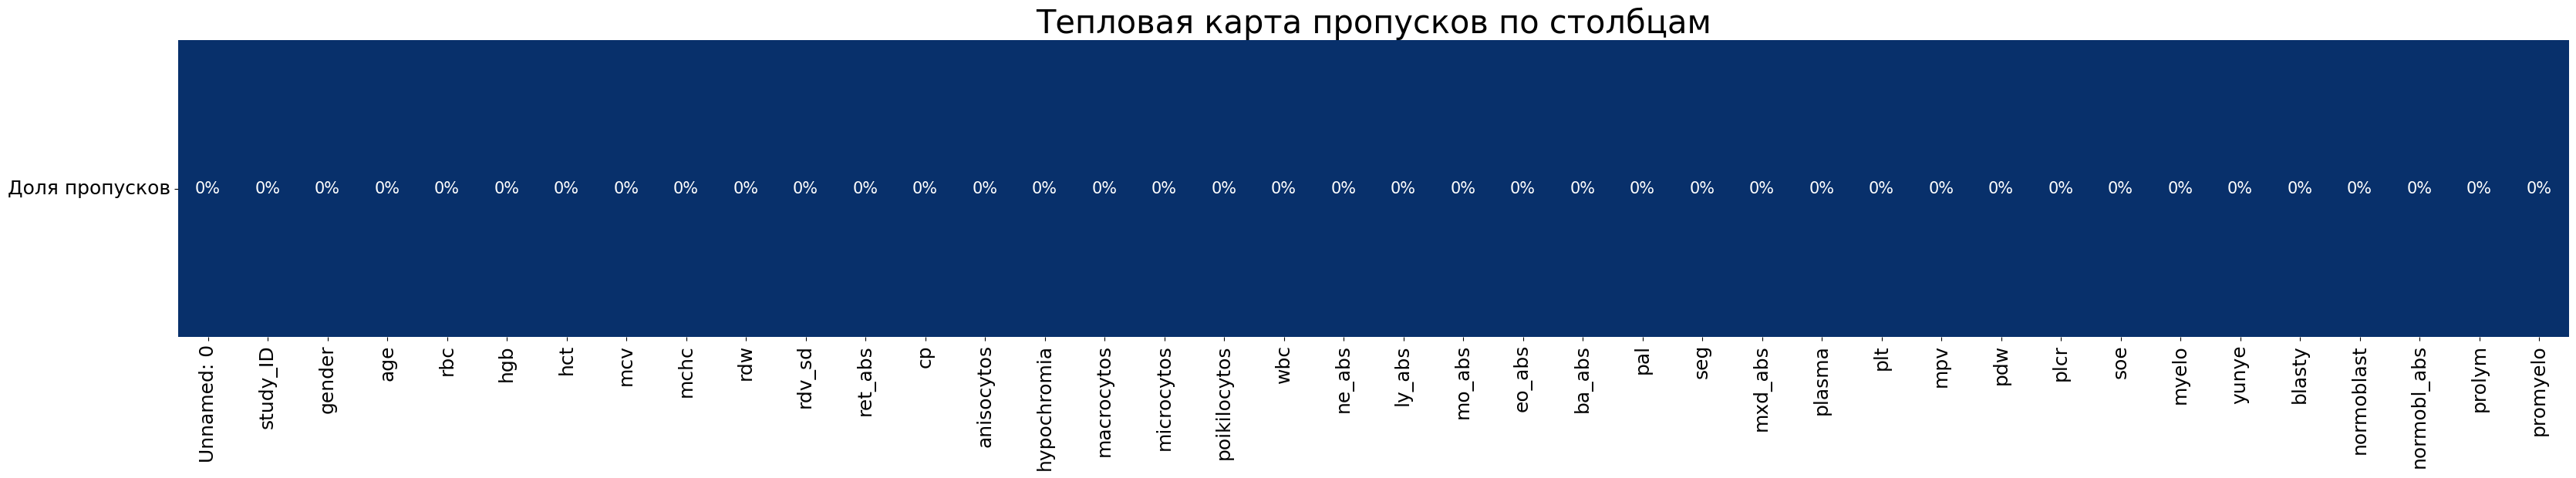

In [14]:
mask = df.isna()

prop_missings = mask.sum()/mask.count()

#преобразуем в DataFrame для построения тепловой карты
df_prop_missings = pd.DataFrame(prop_missings.values.reshape(1, -1),
                                columns=prop_missings.index,
                                index=['Доля пропусков'])

#тепловая карта пропусков
plt.figure(figsize=(40, 5))
sns.heatmap(df_prop_missings, annot=True, fmt='.0%',
            cmap='Blues_r', cbar=False, annot_kws={'fontsize': 15})
plt.title("Тепловая карта пропусков по столбцам", fontsize=30)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18, rotation=0)
plt.show()

##Исследовательский анализ

In [15]:
df = df.drop('Unnamed: 0', axis = 1)

In [16]:
df.head(2)

,study_ID,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo
0,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,0,87,2.21,84.0,26.3,119.1,320.0,21.300000,52.144544,36.245919,1.140000,0.0,0.0,0.0,0.0,0.0,10.0,6.500000,1.300000,1.500000,0.200000,0.000000,3.000000,67.000000,0.294582,0.0,100.000000,7.579015,16.438954,0.0,12.000000,1.0,2.0,0.0,0.0,0.0,0.0,0.0
1,05deb1af-cf40-11e9-80ba-901b0e633689_result_1803,0,87,1.91,74.0,23.6,123.8,315.0,12.280473,41.106126,33.459317,0.903516,0.0,0.0,0.0,0.0,0.0,9.1,5.267876,4.590942,0.514909,0.416559,0.037165,4.772653,59.783114,0.508563,0.0,219.848188,7.908197,16.905172,0.0,3.174857,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
df.columns

Index(['study_ID', 'gender', 'age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw',
       'rdv_sd', 'ret_abs', 'cp', 'anisocytos', 'hypochromia', 'macrocytos',
       'microcytos', 'poikilocytos', 'wbc', 'ne_abs', 'ly_abs', 'mo_abs',
       'eo_abs', 'ba_abs', 'pal', 'seg', 'mxd_abs', 'plasma', 'plt', 'mpv',
       'pdw', 'plcr', 'soe', 'myelo', 'yunye', 'blasty', 'normoblast',
       'normobl_abs', 'prolym', 'promyelo'],
      dtype='object')

In [18]:
bool_col = ['gender', 'anisocytos', 'hypochromia',
            'macrocytos','microcytos', 'poikilocytos',
            'normoblast', 'promyelo']

num_col = ['age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw',
           'rdv_sd', 'ret_abs', 'cp', 'wbc', 'ne_abs', 'ly_abs',
           'mo_abs', 'eo_abs', 'ba_abs', 'pal', 'seg', 'mxd_abs',
           'plasma', 'plt', 'mpv', 'pdw', 'plcr', 'soe', 'myelo',
           'yunye', 'blasty', 'normobl_abs']

cat_col = ['prolym']

Исследовательский анализ age


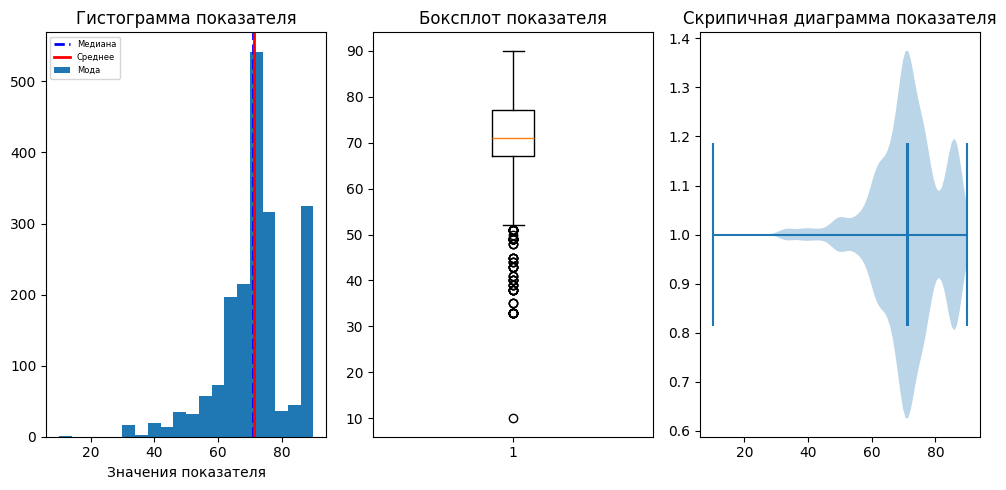

Показатели описательной статистики
count    1924.000000
mean       71.284823
std        10.661431
min        10.000000
25%        67.000000
50%        71.000000
75%        77.000000
max        90.000000
Name: age, dtype: float64
Мода в данных по показателю: 0    71
Name: age, dtype: int64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rbc


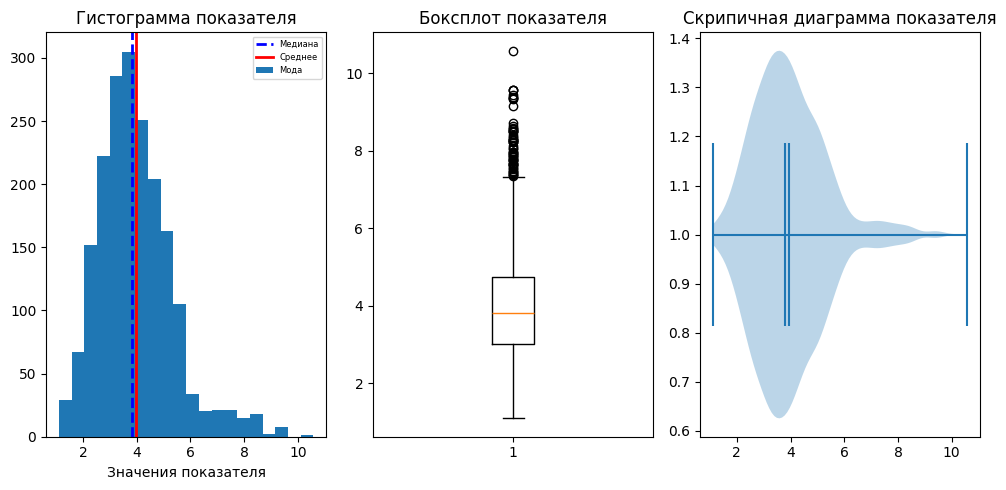

Показатели описательной статистики
count    1924.000000
mean        3.955733
std         1.385590
min         1.100000
25%         3.020000
50%         3.810000
75%         4.741107
max        10.580000
Name: rbc, dtype: float64
Мода в данных по показателю: 0    3.53
1    3.61
2    3.73
Name: rbc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ hgb


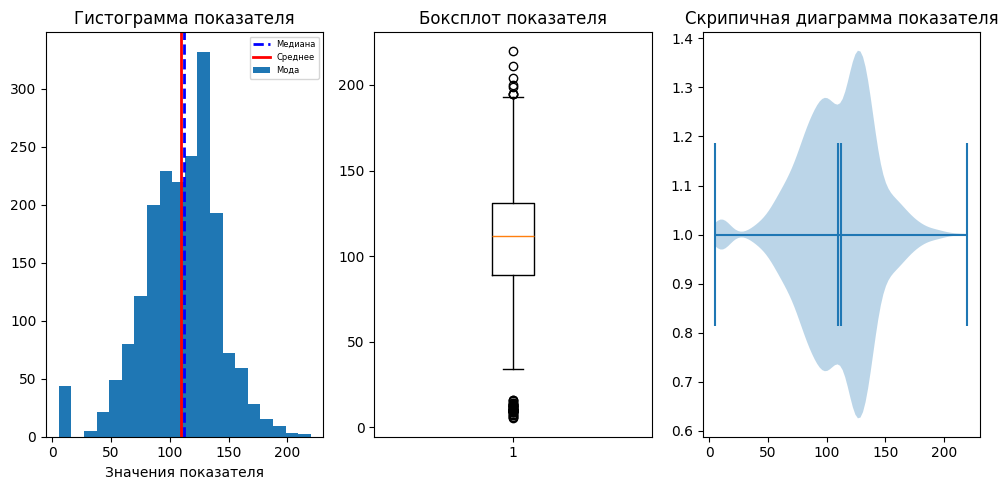

Показатели описательной статистики
count    1924.000000
mean      109.388949
std        32.461667
min         5.344828
25%        89.000000
50%       112.000000
75%       131.000000
max       220.000000
Name: hgb, dtype: float64
Мода в данных по показателю: 0    111.0
Name: hgb, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ hct


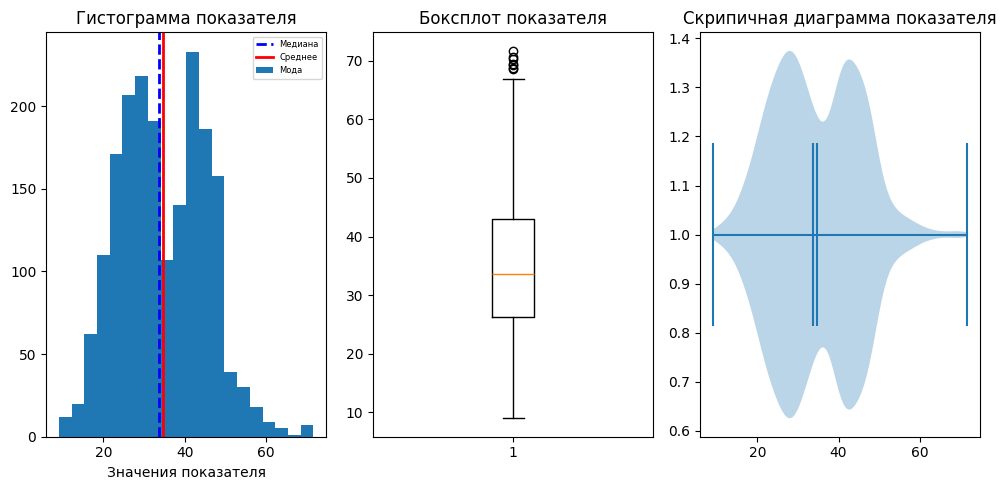

Показатели описательной статистики
count    1924.000000
mean       34.655022
std        10.620728
min         9.000000
25%        26.200000
50%        33.700000
75%        43.000000
max        71.700000
Name: hct, dtype: float64
Мода в данных по показателю: 0    28.0
Name: hct, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mcv


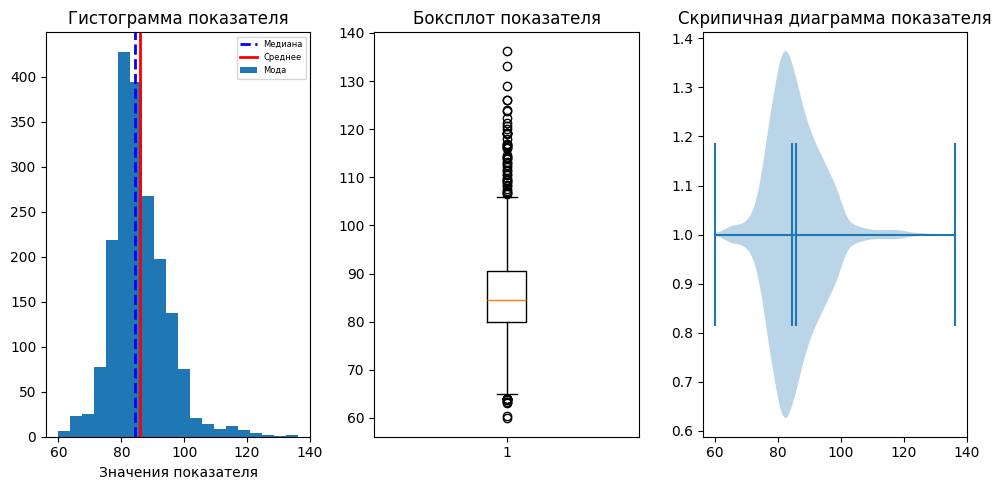

Показатели описательной статистики
count    1924.000000
mean       85.813017
std         8.905726
min        59.900000
25%        80.000000
50%        84.480120
75%        90.525000
max       136.300000
Name: mcv, dtype: float64
Мода в данных по показателю: 0    81.0
Name: mcv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mchc


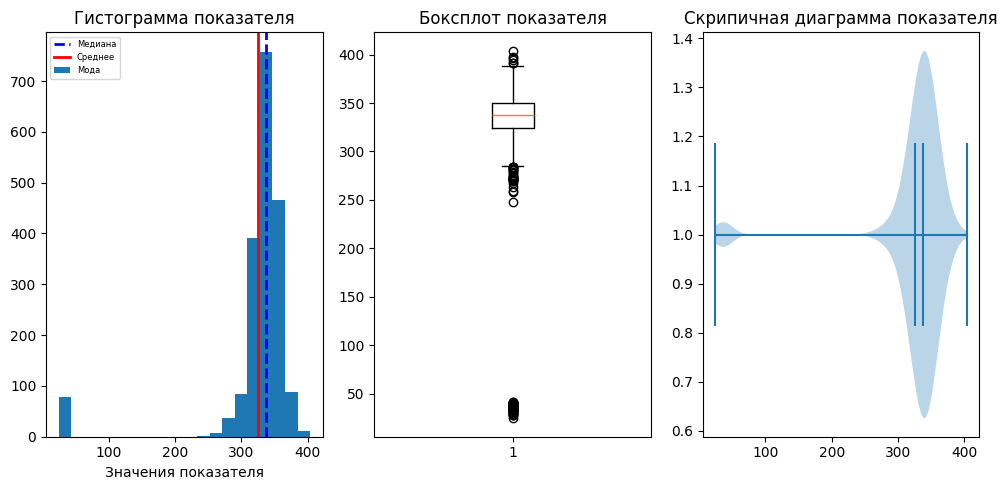

Показатели описательной статистики
count    1924.000000
mean      325.419657
std        62.922962
min        24.400000
25%       324.000000
50%       338.000000
75%       350.000000
max       404.000000
Name: mchc, dtype: float64
Мода в данных по показателю: 0    344.0
Name: mchc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rdw


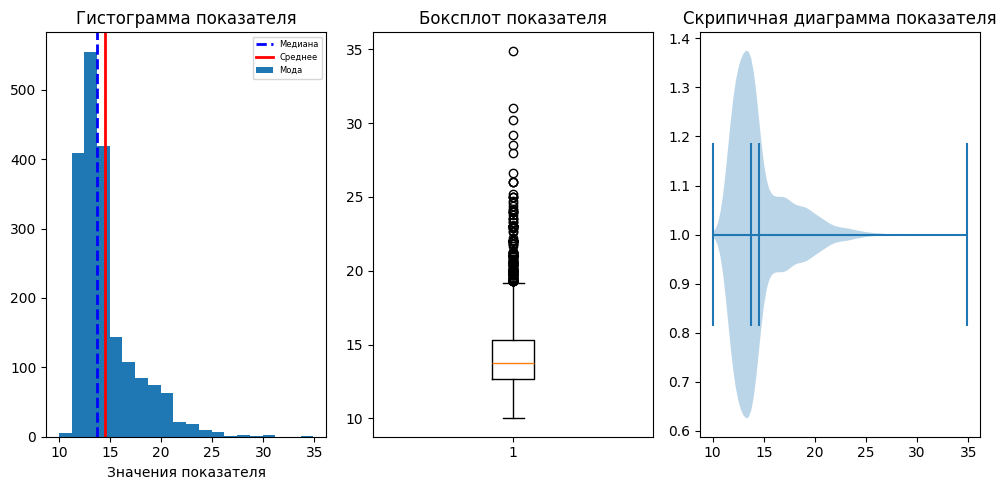

Показатели описательной статистики
count    1924.000000
mean       14.546764
std         2.866564
min        10.000000
25%        12.655785
50%        13.717941
75%        15.300000
max        34.900000
Name: rdw, dtype: float64
Мода в данных по показателю: 0    14.0
Name: rdw, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rdv_sd


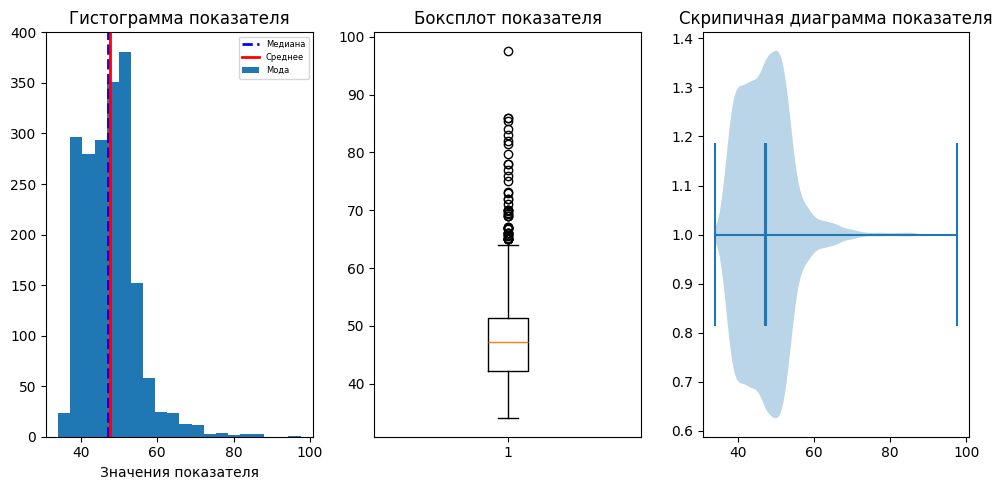

Показатели описательной статистики
count    1924.000000
mean       47.508011
std         7.079592
min        34.000000
25%        42.209749
50%        47.146982
75%        51.304203
max        97.600000
Name: rdv_sd, dtype: float64
Мода в данных по показателю: 0    52.0
Name: rdv_sd, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ret_abs


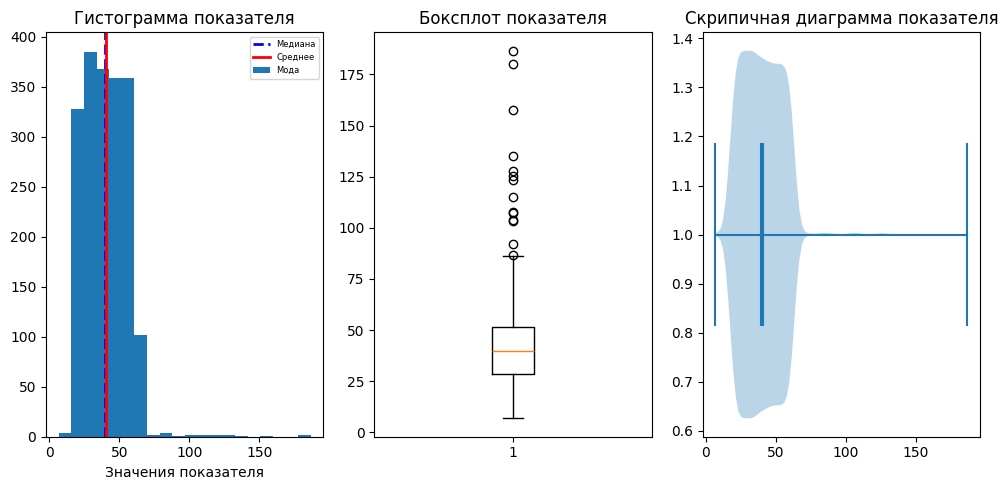

Показатели описательной статистики
count    1924.000000
mean       40.508569
std        15.442723
min         6.800000
25%        28.413682
50%        39.662452
75%        51.713159
max       186.600000
Name: ret_abs, dtype: float64
Мода в данных по показателю: 0         6.800000
1        10.000000
2        11.800000
3        14.500000
4        17.010444
           ...    
1919    128.000000
1920    134.900000
1921    157.600000
1922    180.200000
1923    186.600000
Name: ret_abs, Length: 1924, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ cp


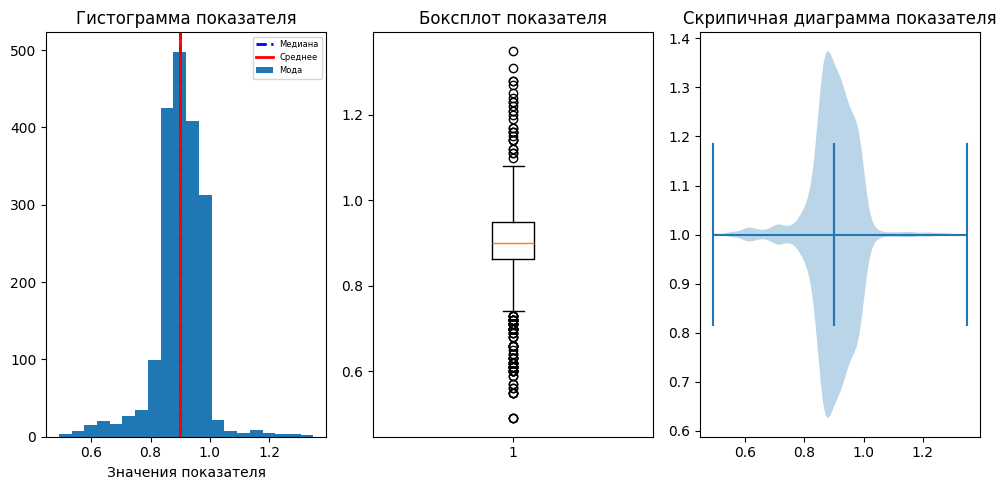

Показатели описательной статистики
count    1924.000000
mean        0.900274
std         0.084162
min         0.490000
25%         0.861867
50%         0.900769
75%         0.949577
max         1.350000
Name: cp, dtype: float64
Мода в данных по показателю: 0    0.86
Name: cp, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ wbc


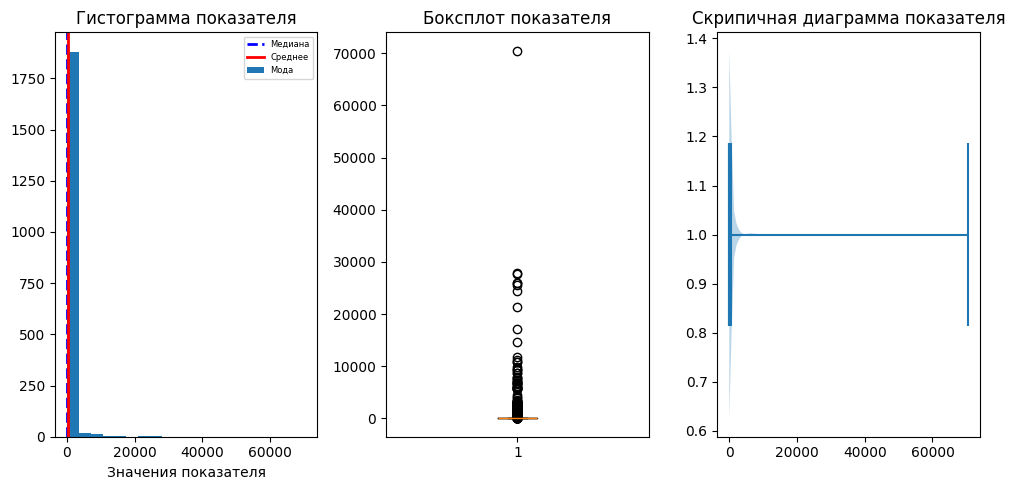

Показатели описательной статистики
count     1924.000000
mean       467.047345
std       2523.012487
min          0.000000
25%          4.627500
50%          7.700000
75%         13.477500
max      70500.000000
Name: wbc, dtype: float64
Мода в данных по показателю: 0    1.0
Name: wbc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ne_abs


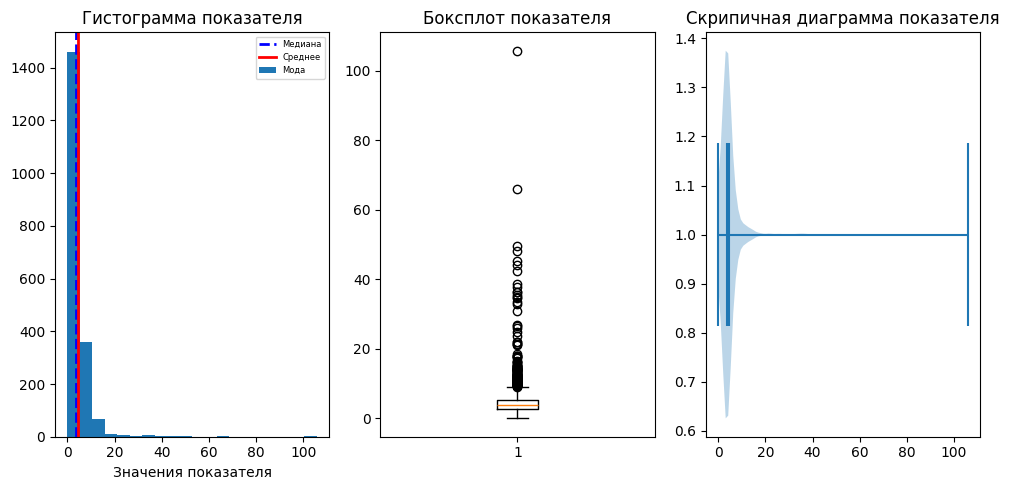

Показатели описательной статистики
count    1924.000000
mean        4.649797
std         5.116192
min         0.000000
25%         2.600000
50%         3.820280
75%         5.200000
max       105.700000
Name: ne_abs, dtype: float64
Мода в данных по показателю: 0    0.3
Name: ne_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ly_abs


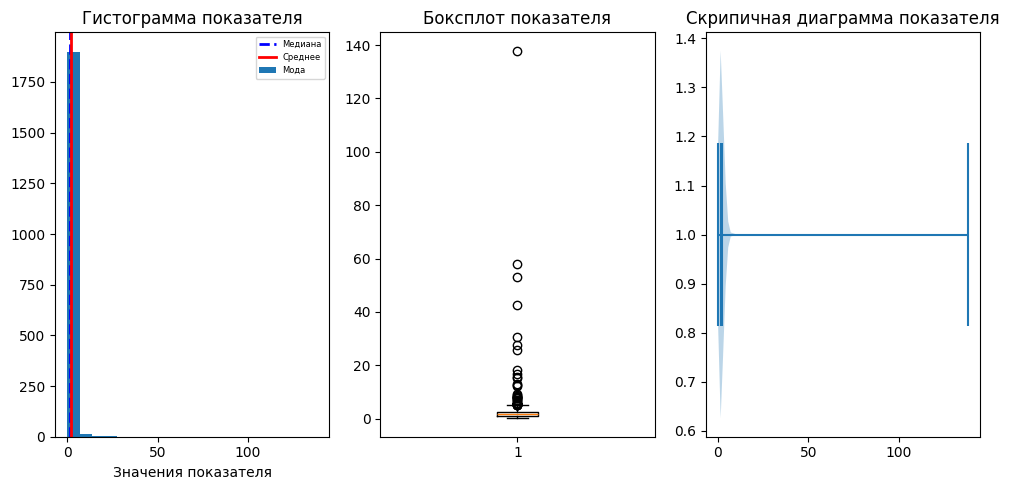

Показатели описательной статистики
count    1924.000000
mean        2.221188
std         4.081464
min         0.100000
25%         1.057753
50%         1.700000
75%         2.657676
max       137.900000
Name: ly_abs, dtype: float64
Мода в данных по показателю: 0    1.0
Name: ly_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mo_abs


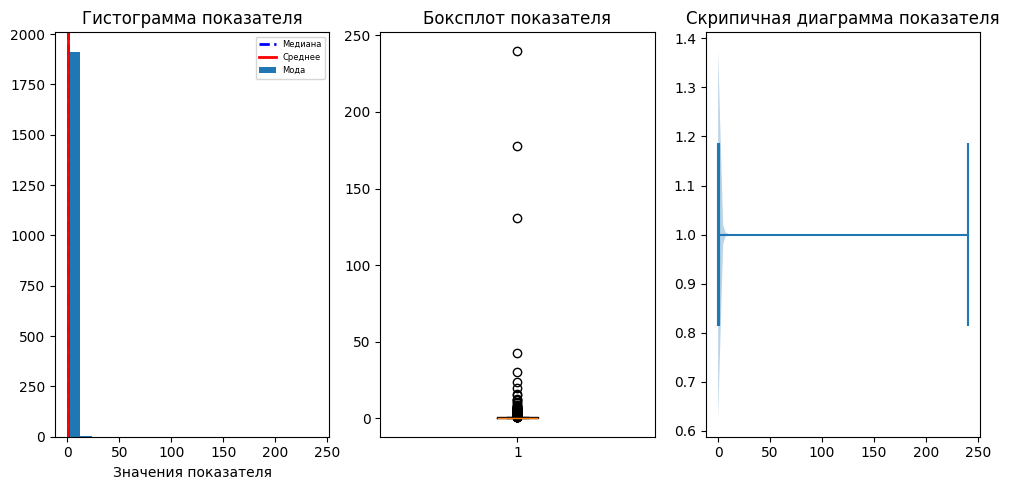

Показатели описательной статистики
count    1924.000000
mean        0.891831
std         7.603387
min         0.000000
25%         0.200000
50%         0.377895
75%         0.562526
max       239.930000
Name: mo_abs, dtype: float64
Мода в данных по показателю: 0    0.2
Name: mo_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ eo_abs


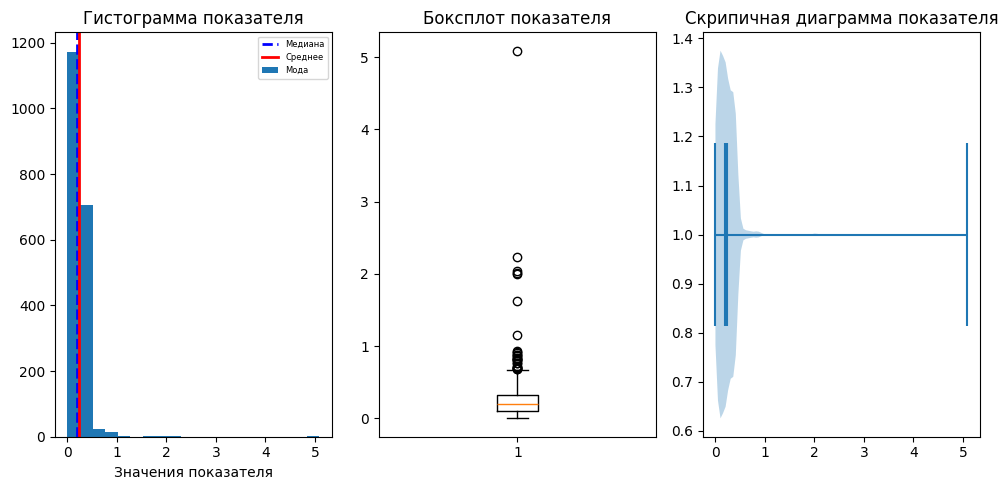

Показатели описательной статистики
count    1924.000000
mean        0.224538
std         0.208413
min         0.000000
25%         0.100000
50%         0.200000
75%         0.330000
max         5.090000
Name: eo_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: eo_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ba_abs


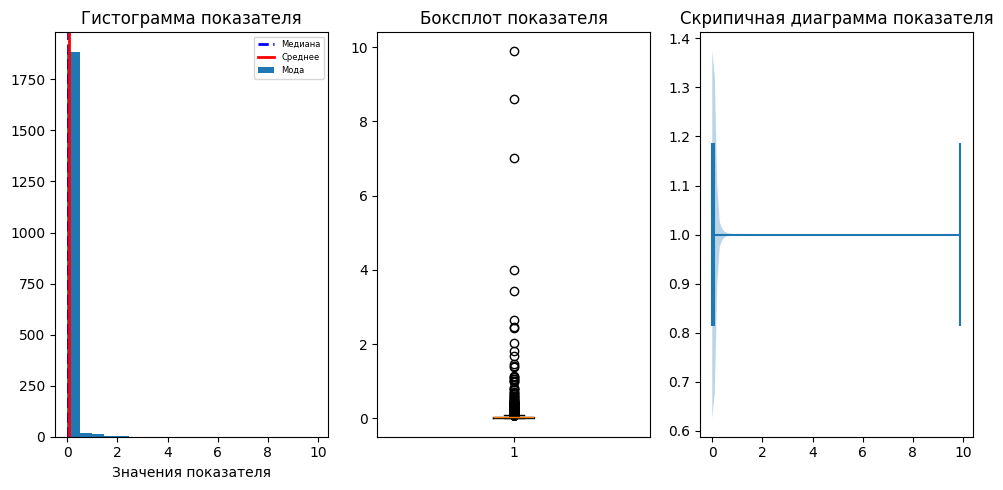

Показатели описательной статистики
count    1924.000000
mean        0.087079
std         0.393883
min         0.000000
25%         0.020000
50%         0.034503
75%         0.049018
max         9.900000
Name: ba_abs, dtype: float64
Мода в данных по показателю: 0    0.1
Name: ba_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ pal


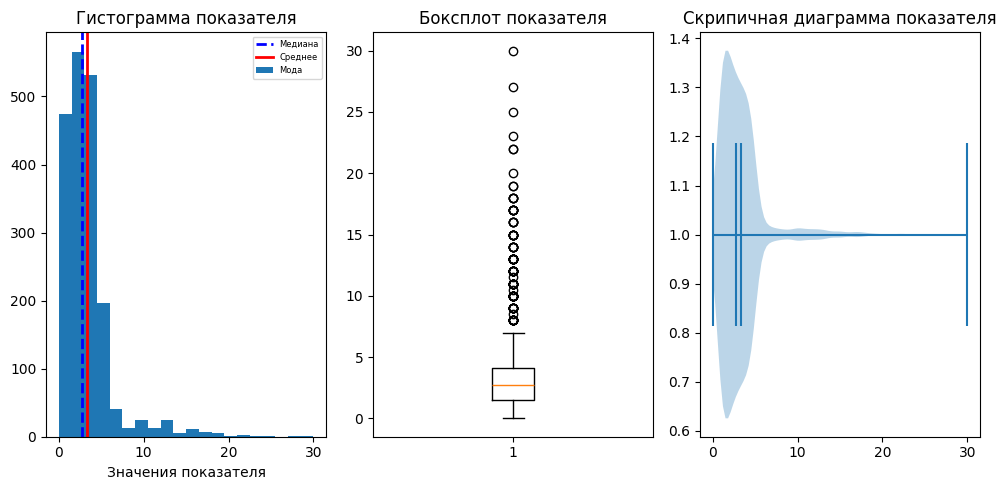

Показатели описательной статистики
count    1924.000000
mean        3.302826
std         2.941806
min         0.000000
25%         1.516688
50%         2.735560
75%         4.073108
max        30.000000
Name: pal, dtype: float64
Мода в данных по показателю: 0    1.0
Name: pal, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ seg


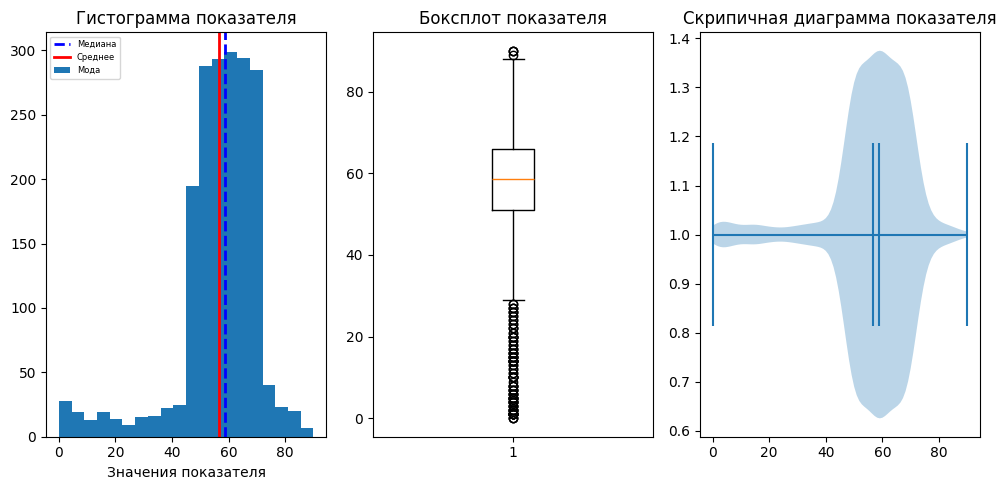

Показатели описательной статистики
count    1924.000000
mean       56.586813
std        14.340665
min         0.000000
25%        51.000000
50%        58.648441
75%        66.000000
max        90.000000
Name: seg, dtype: float64
Мода в данных по показателю: 0    60.0
Name: seg, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mxd_abs


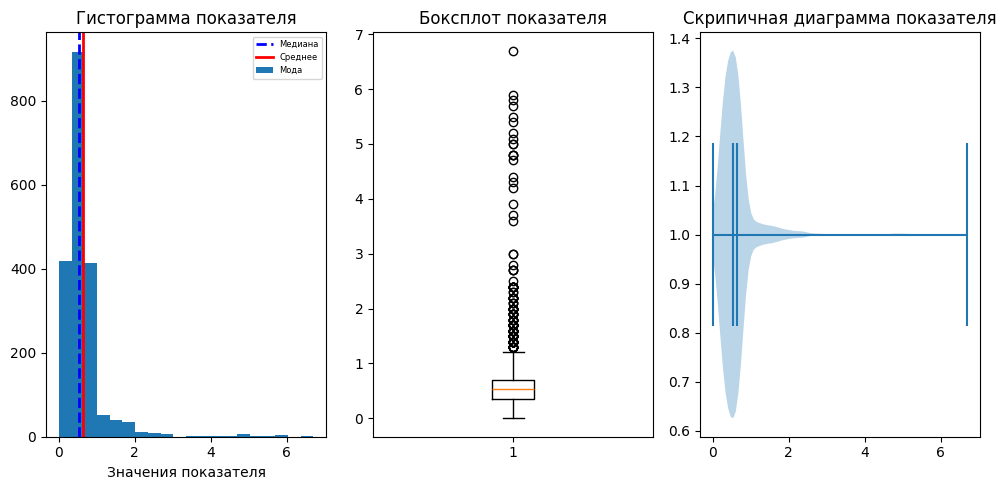

Показатели описательной статистики
count    1924.000000
mean        0.638301
std         0.588640
min         0.000000
25%         0.360264
50%         0.532149
75%         0.700575
max         6.700000
Name: mxd_abs, dtype: float64
Мода в данных по показателю: 0    0.6
Name: mxd_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plasma


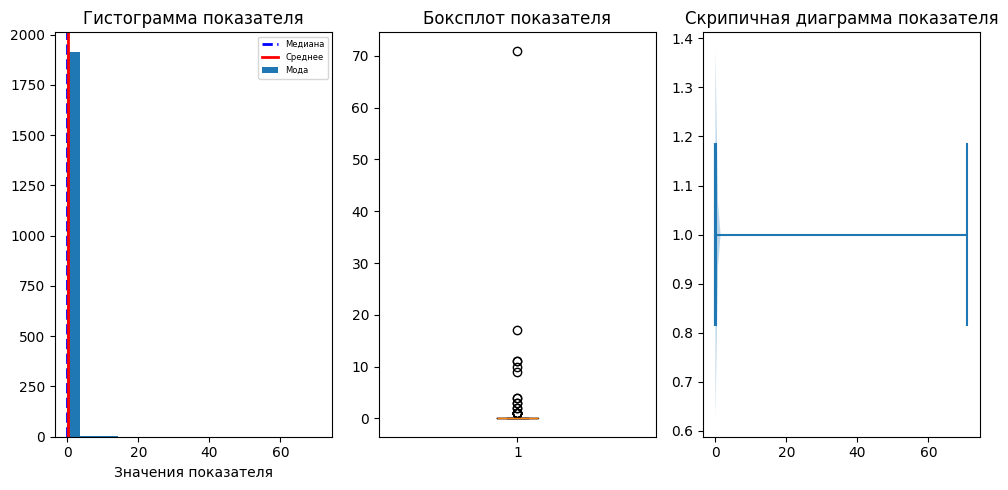

Показатели описательной статистики
count    1924.000000
mean        0.080561
std         1.737673
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        71.000000
Name: plasma, dtype: float64
Мода в данных по показателю: 0    0.0
Name: plasma, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plt


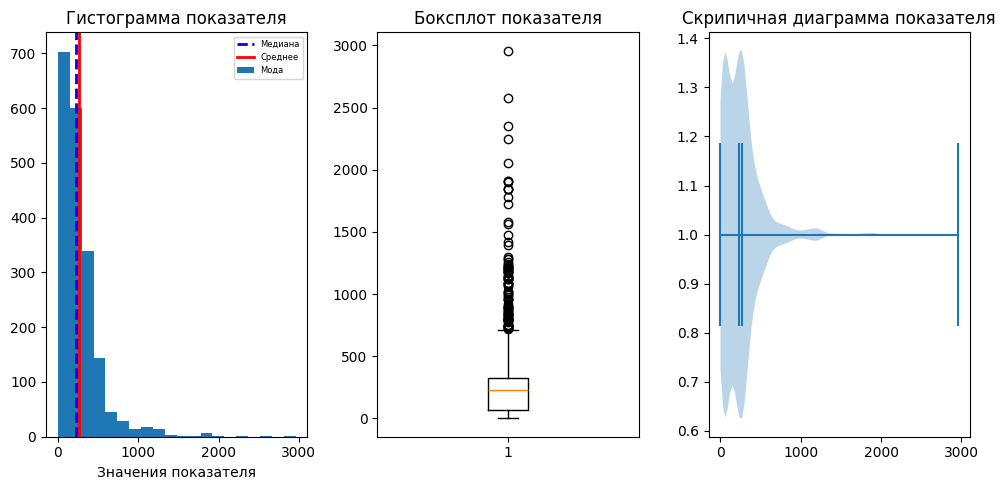

Показатели описательной статистики
count    1924.000000
mean      265.347966
std       274.989680
min         0.000000
25%        71.000000
50%       226.584509
75%       328.475000
max      2958.000000
Name: plt, dtype: float64
Мода в данных по показателю: 0    36.0
Name: plt, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mpv


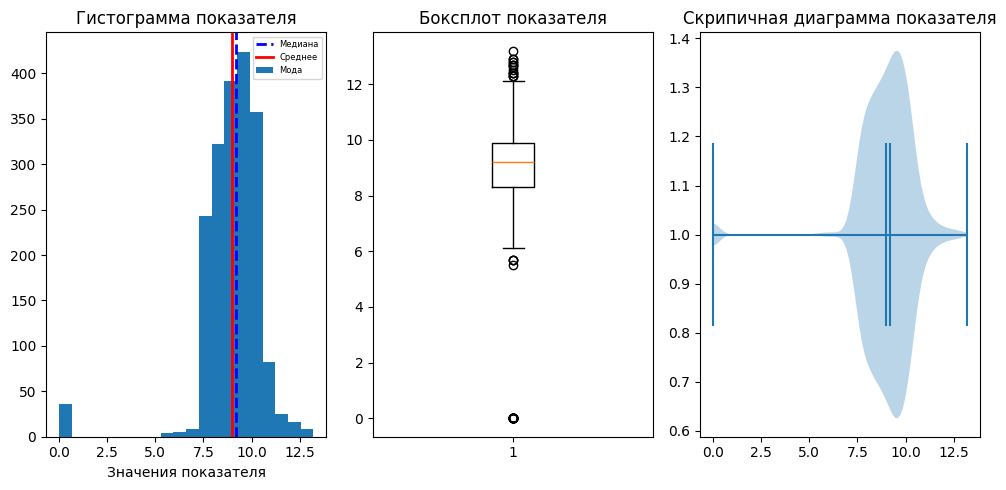

Показатели описательной статистики
count    1924.000000
mean        8.996490
std         1.616446
min         0.000000
25%         8.309910
50%         9.200000
75%         9.900000
max        13.200000
Name: mpv, dtype: float64
Мода в данных по показателю: 0    9.5
1    9.9
Name: mpv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ pdw


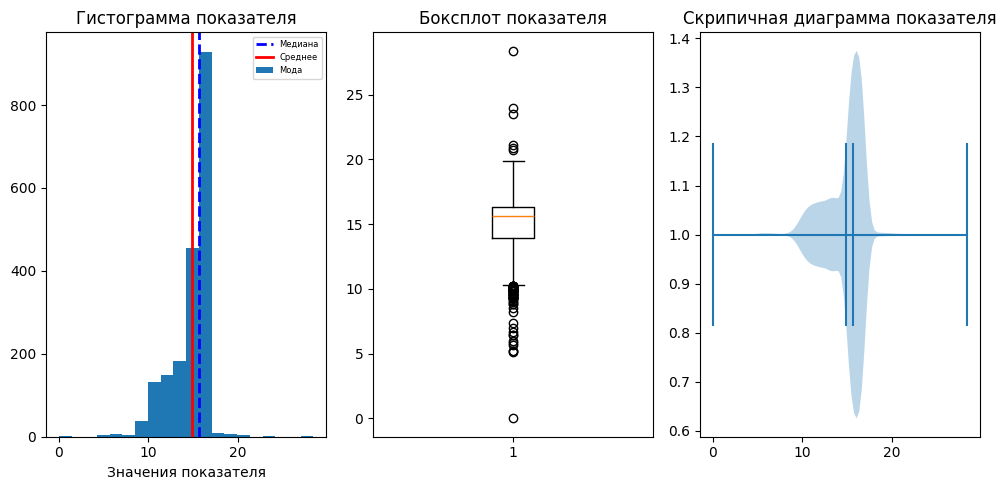

Показатели описательной статистики
count    1924.000000
mean       14.902139
std         2.172698
min         0.000000
25%        13.900000
50%        15.600000
75%        16.362889
max        28.400000
Name: pdw, dtype: float64
Мода в данных по показателю: 0    11.7
1    13.5
Name: pdw, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plcr


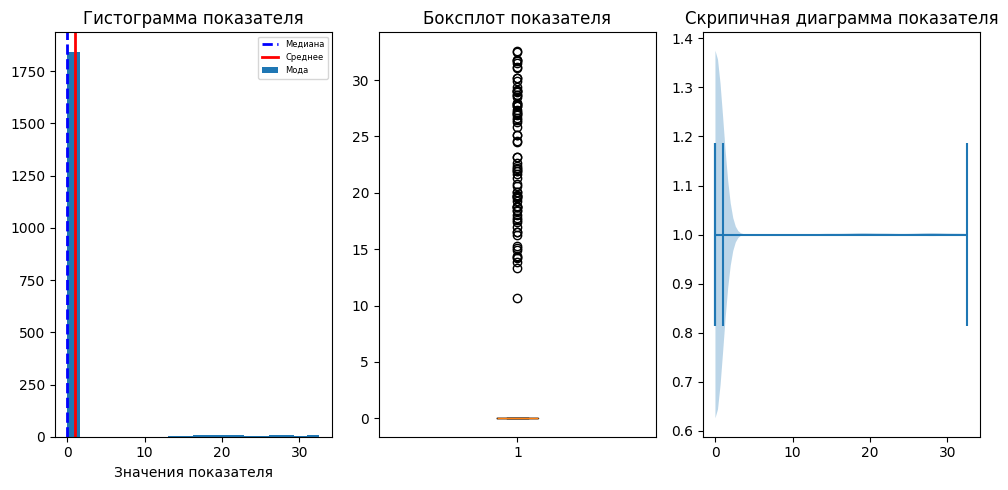

Показатели описательной статистики
count    1924.000000
mean        0.962422
std         4.763007
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        32.600000
Name: plcr, dtype: float64
Мода в данных по показателю: 0    0.0
Name: plcr, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ soe


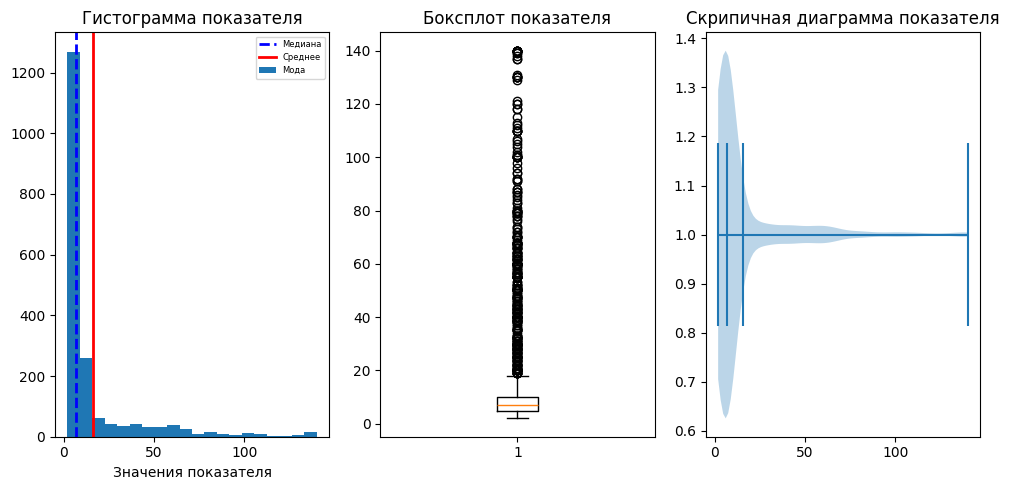

Показатели описательной статистики
count    1924.000000
mean       16.010829
std        24.208787
min         2.000000
25%         4.589440
50%         7.000000
75%         9.955712
max       140.000000
Name: soe, dtype: float64
Мода в данных по показателю: 0    4.0
Name: soe, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ myelo


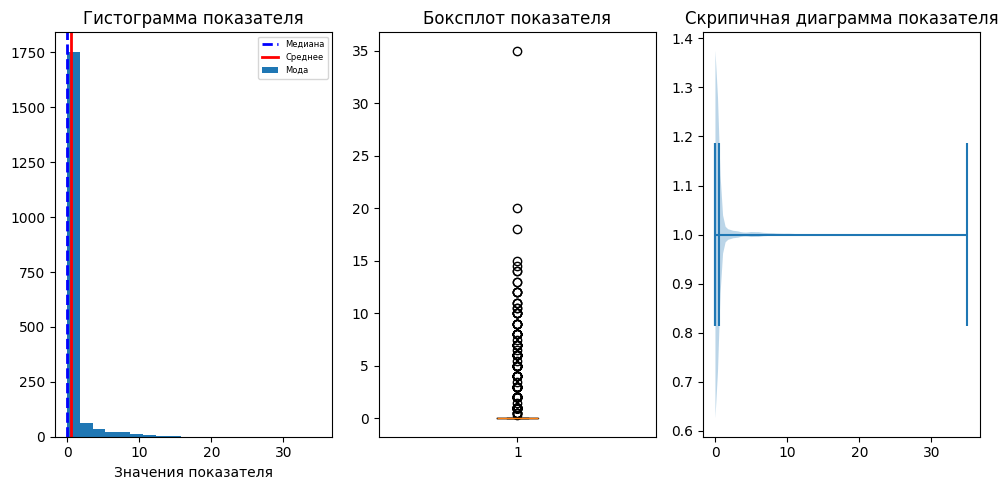

Показатели описательной статистики
count    1924.000000
mean        0.542775
std         2.041212
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: myelo, dtype: float64
Мода в данных по показателю: 0    0.0
Name: myelo, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ yunye


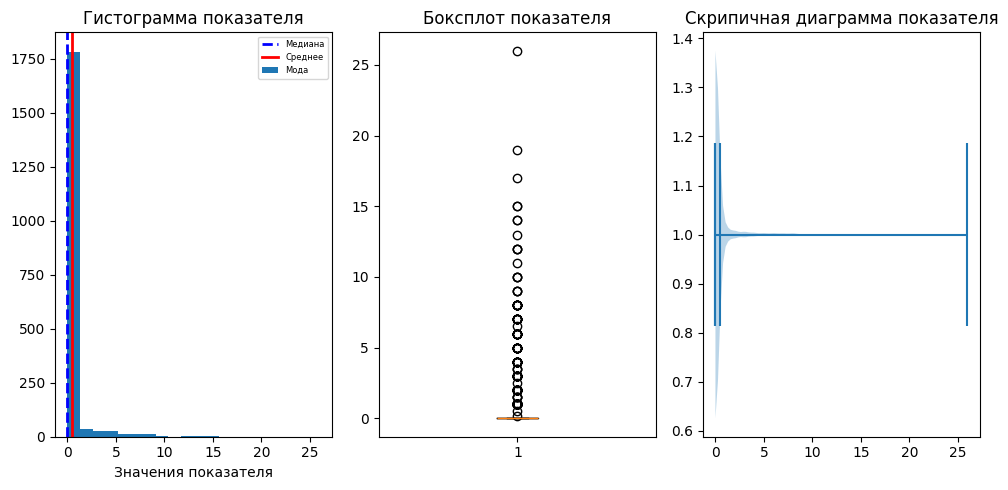

Показатели описательной статистики
count    1924.000000
mean        0.426819
std         1.732356
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        26.000000
Name: yunye, dtype: float64
Мода в данных по показателю: 0    0.0
Name: yunye, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ blasty


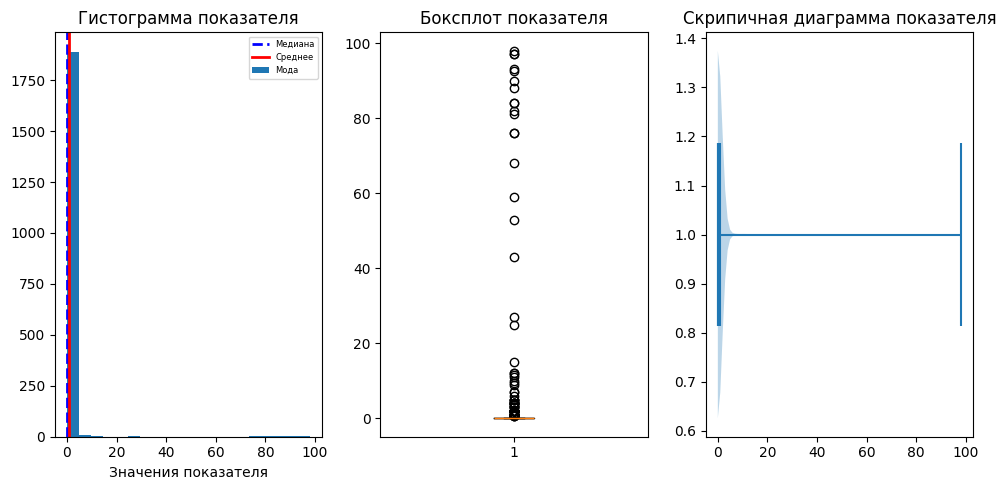

Показатели описательной статистики
count    1924.000000
mean        0.875520
std         7.720832
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        98.000000
Name: blasty, dtype: float64
Мода в данных по показателю: 0    0.0
Name: blasty, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ normobl_abs


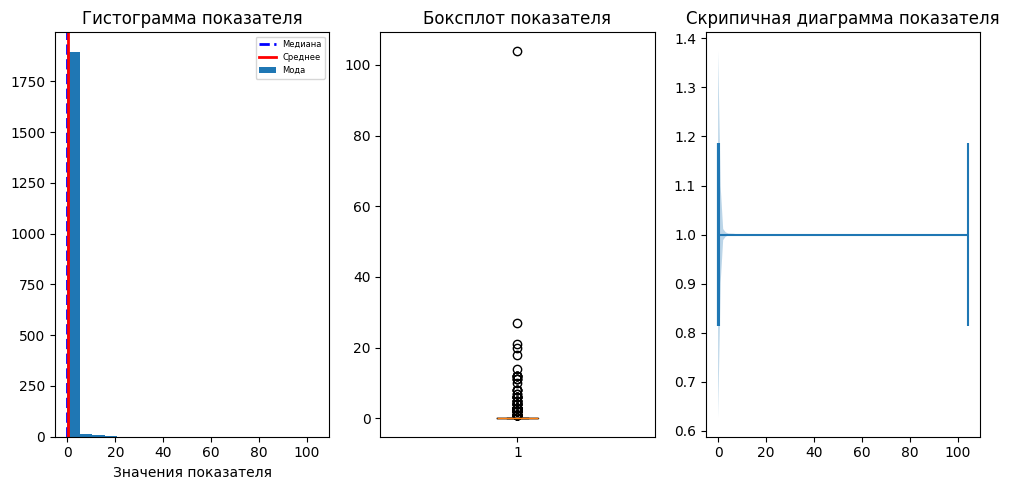

Показатели описательной статистики
count    1924.000000
mean        0.312890
std         2.797336
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       104.000000
Name: normobl_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: normobl_abs, dtype: float64
----------------------------------------------------------------------------------------------------


In [19]:
for col in num_col:
  print(f'Исследовательский анализ {col}')
  analisys_num(df[col])
  print('-'*100)

Исследовательский анализ показателя prolym


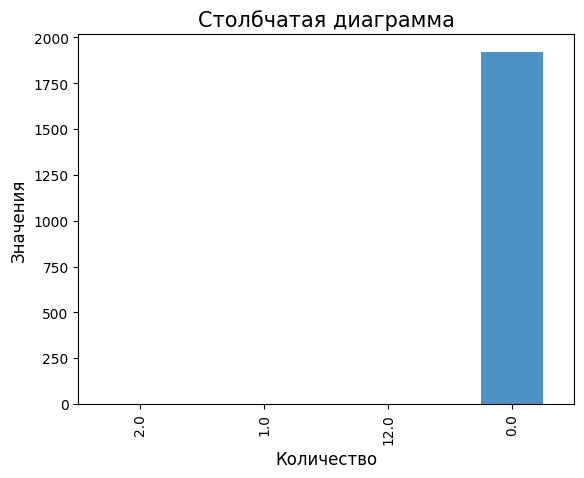

----------------------------------------------------------------------------------------------------


In [20]:
for col in cat_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_cat_plot(df[col])
  print('-'*100)

Исследовательский анализ показателя gender


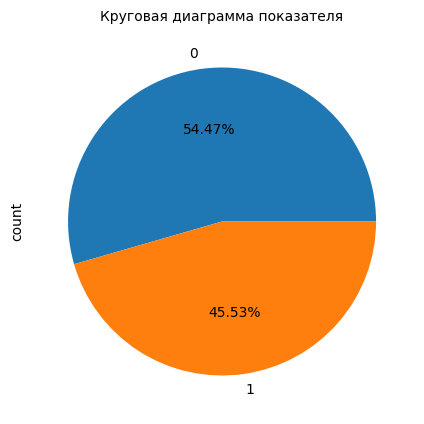

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя anisocytos


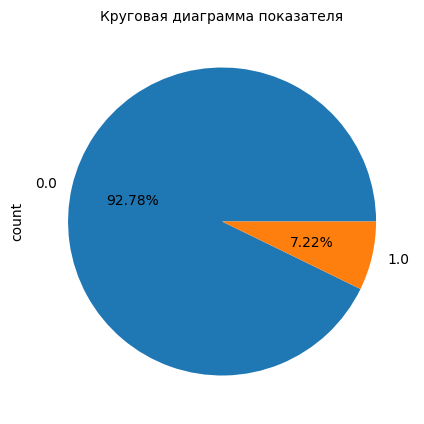

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя hypochromia


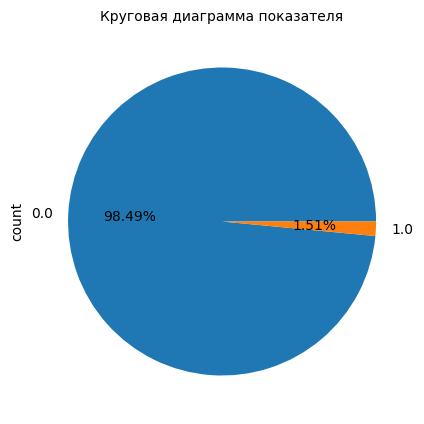

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя macrocytos


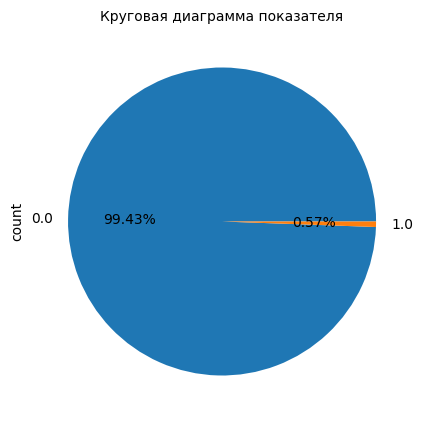

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя microcytos


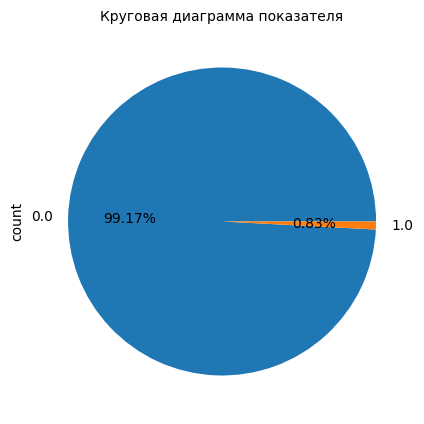

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя poikilocytos


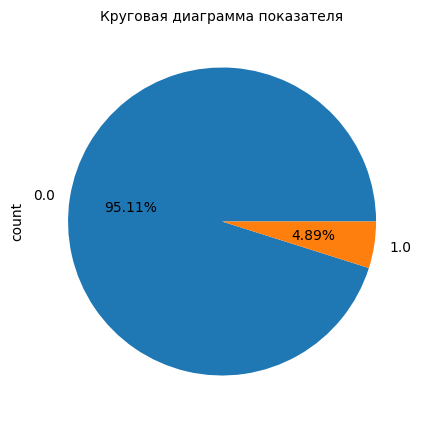

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя normoblast


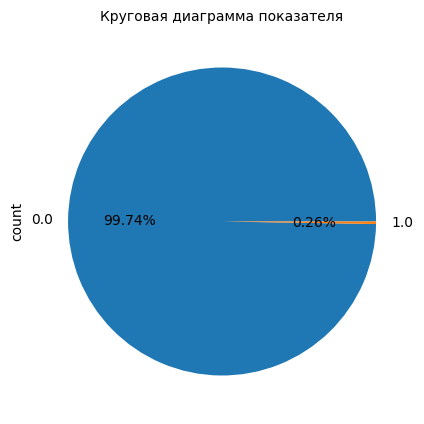

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя promyelo


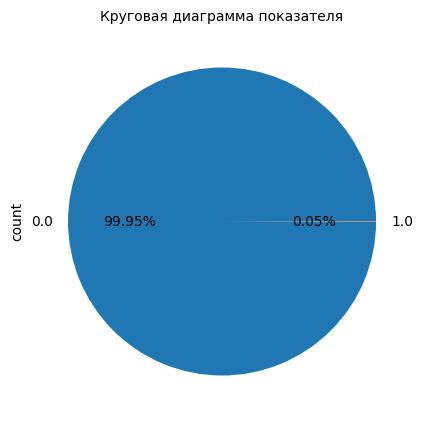

----------------------------------------------------------------------------------------------------


In [21]:
for col in bool_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_cat_pie(df[col])
  print('-'*100)

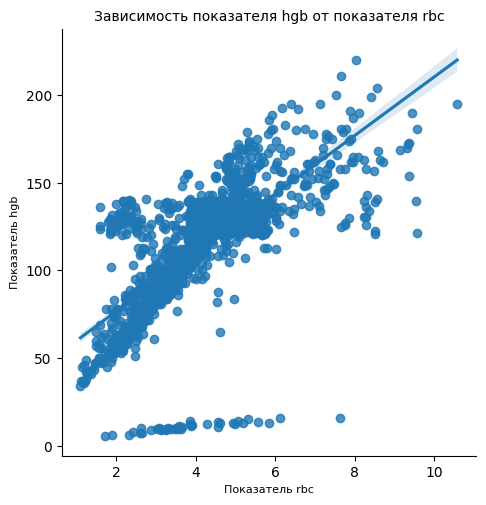

In [22]:
grafic(df, 'rbc', 'hgb')

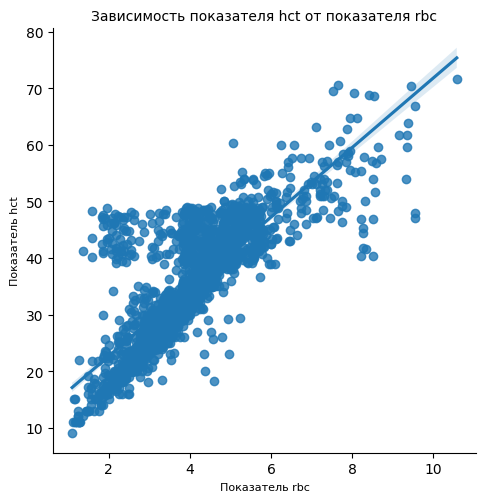

In [23]:
grafic(df, 'rbc', 'hct')

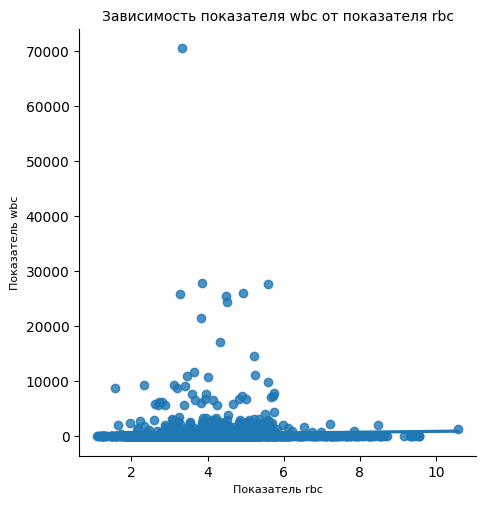

In [24]:
grafic(df, 'rbc', 'wbc')

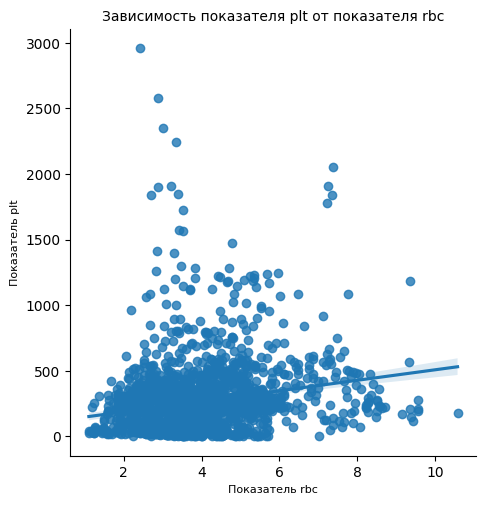

In [25]:
grafic(df, 'rbc', 'plt')

Сравнение распределения показателя age внутри
 представителей разного пола


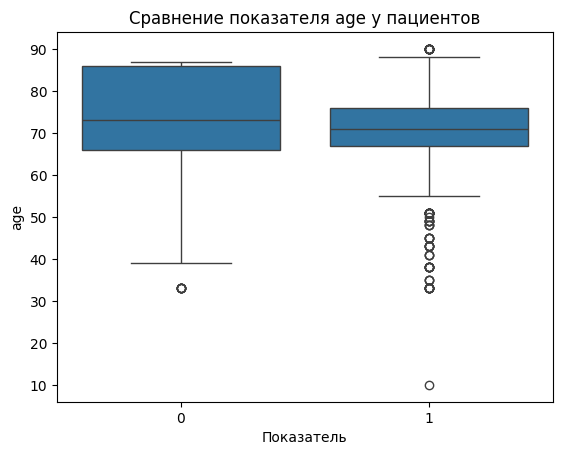

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя rbc внутри
 представителей разного пола


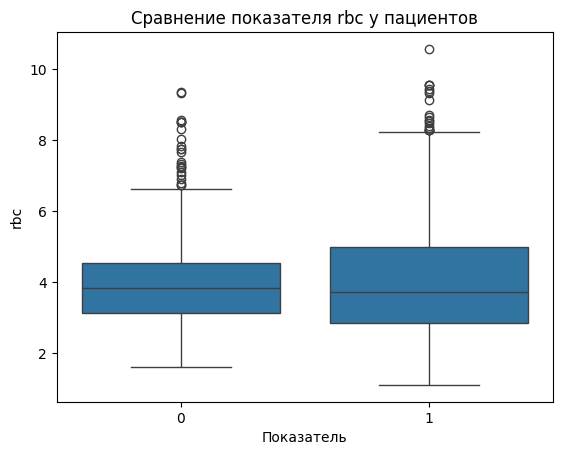

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя hgb внутри
 представителей разного пола


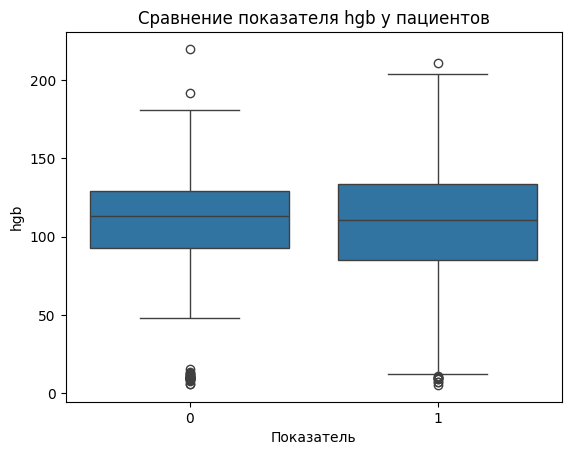

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя hct внутри
 представителей разного пола


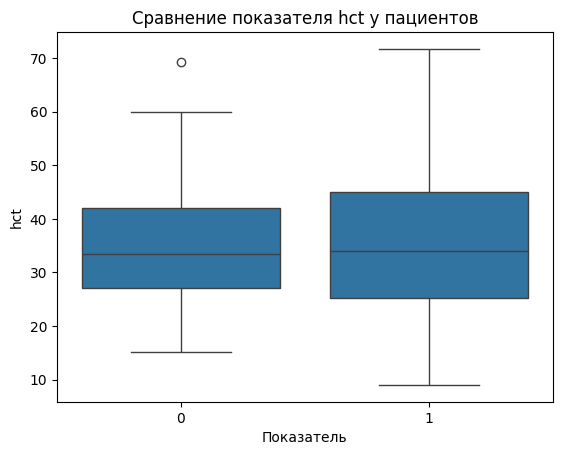

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mcv внутри
 представителей разного пола


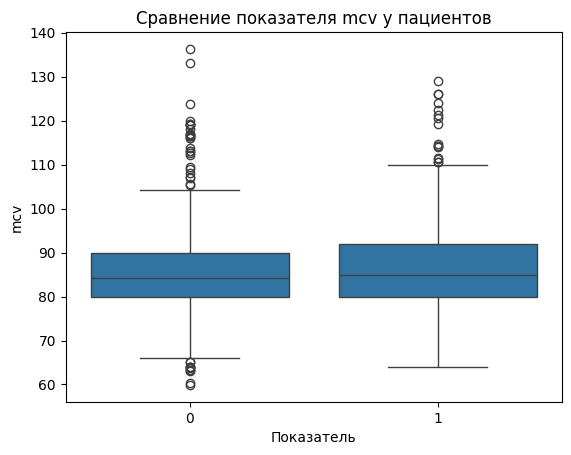

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mchc внутри
 представителей разного пола


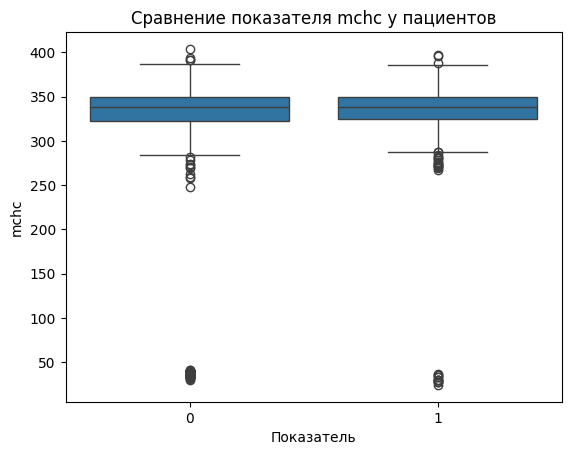

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя rdw внутри
 представителей разного пола


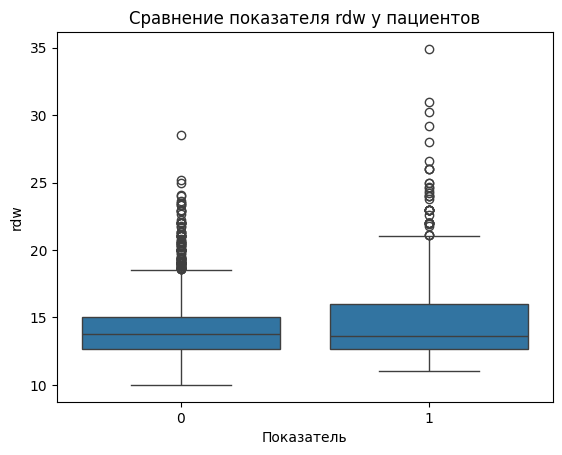

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя rdv_sd внутри
 представителей разного пола


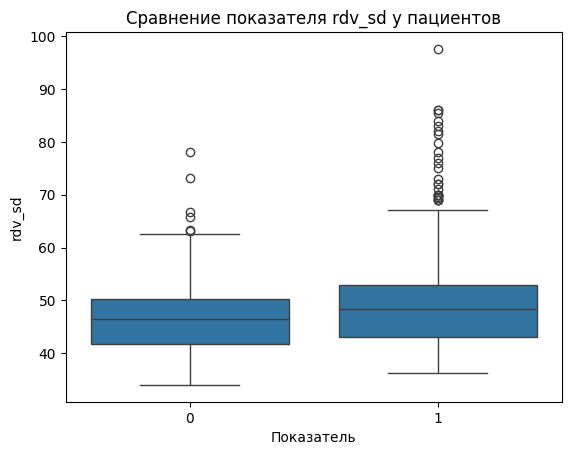

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ret_abs внутри
 представителей разного пола


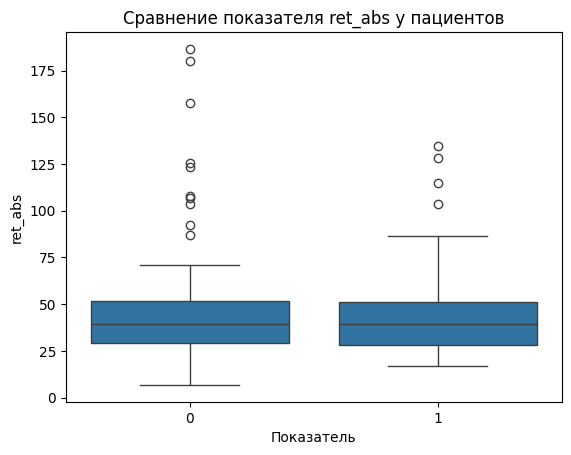

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя cp внутри
 представителей разного пола


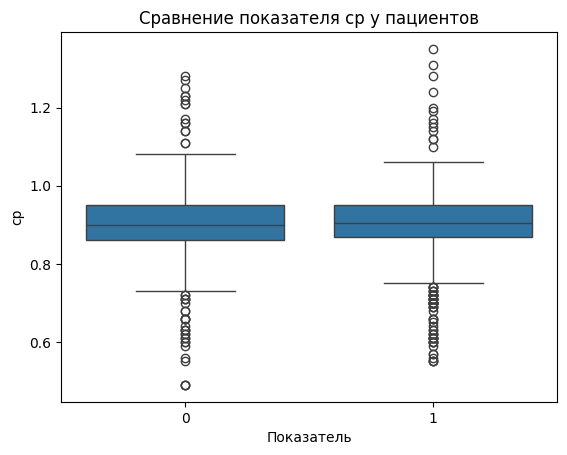

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя wbc внутри
 представителей разного пола


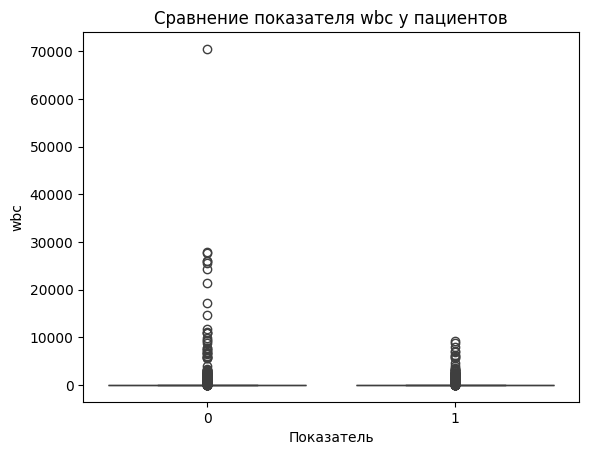

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ne_abs внутри
 представителей разного пола


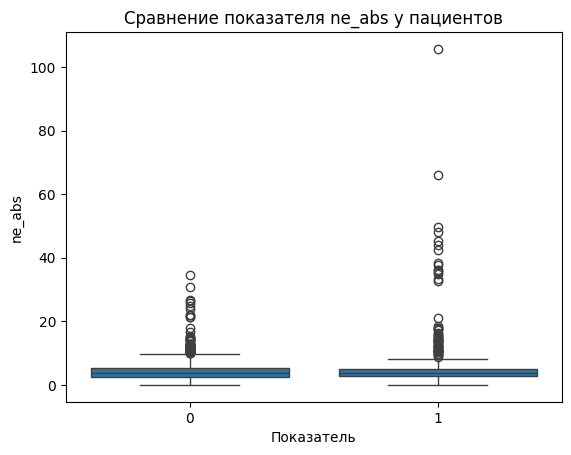

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ly_abs внутри
 представителей разного пола


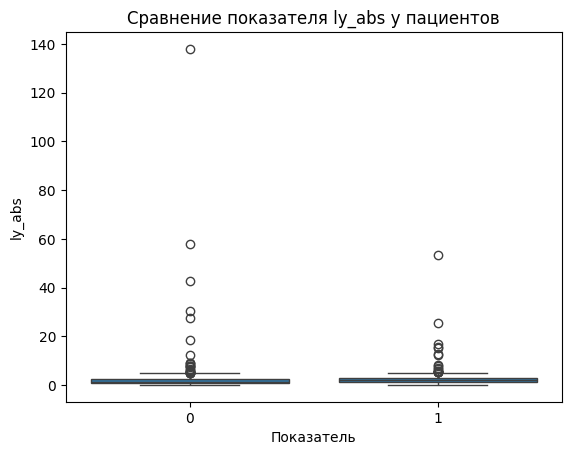

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mo_abs внутри
 представителей разного пола


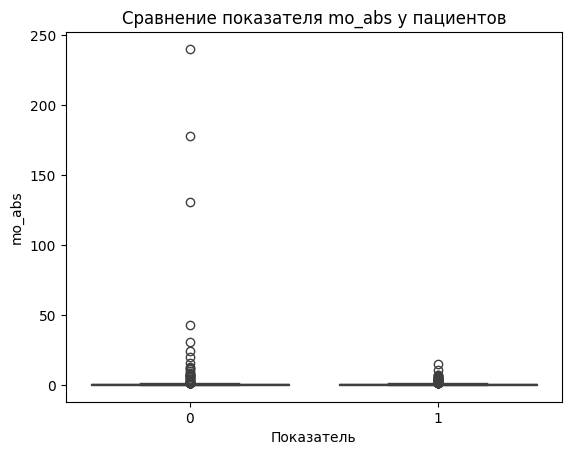

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя eo_abs внутри
 представителей разного пола


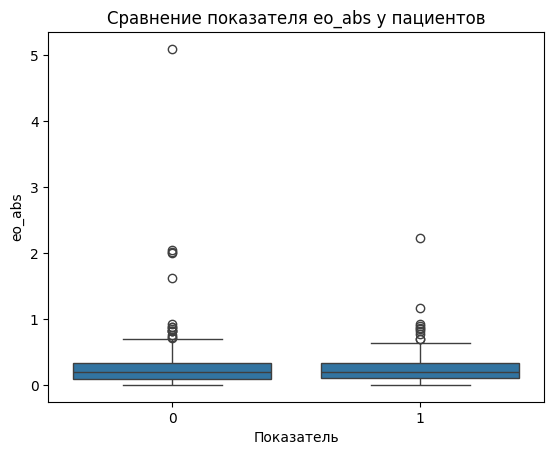

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ba_abs внутри
 представителей разного пола


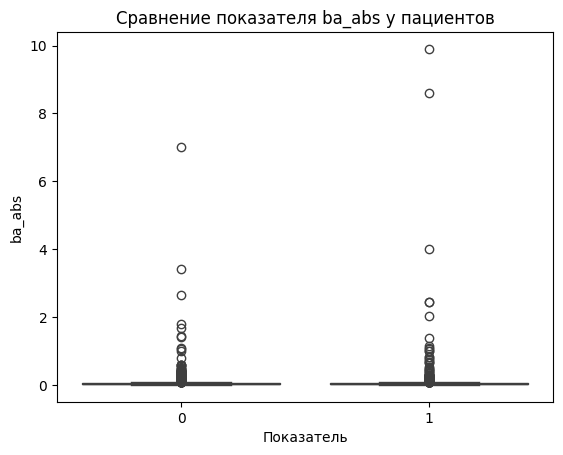

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя pal внутри
 представителей разного пола


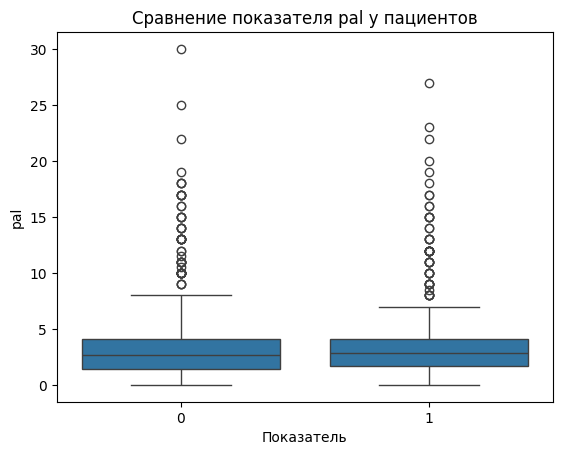

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя seg внутри
 представителей разного пола


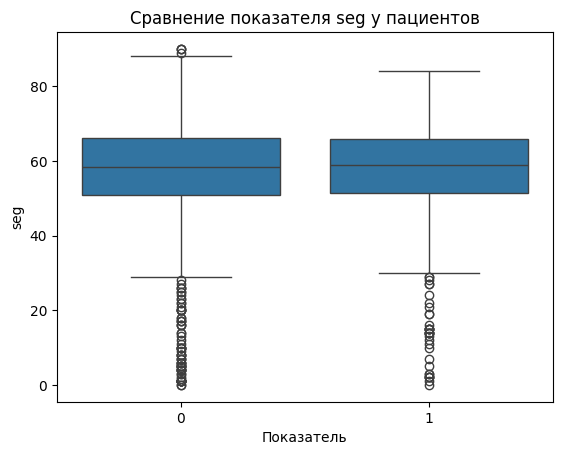

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mxd_abs внутри
 представителей разного пола


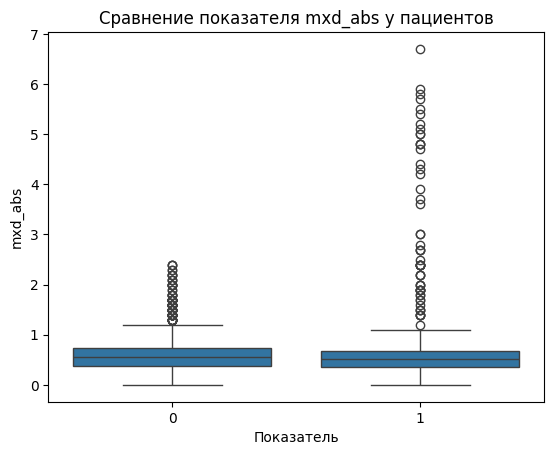

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя plasma внутри
 представителей разного пола


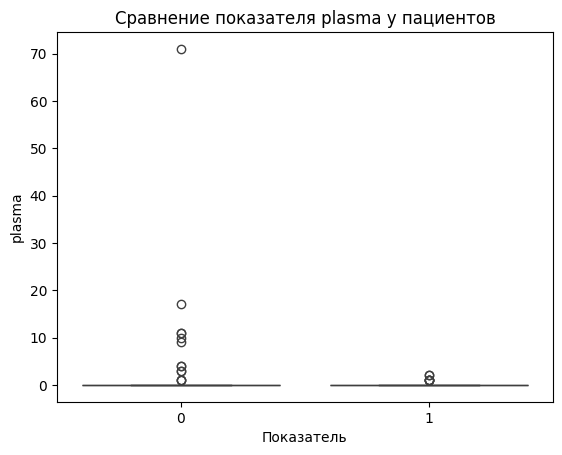

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя plt внутри
 представителей разного пола


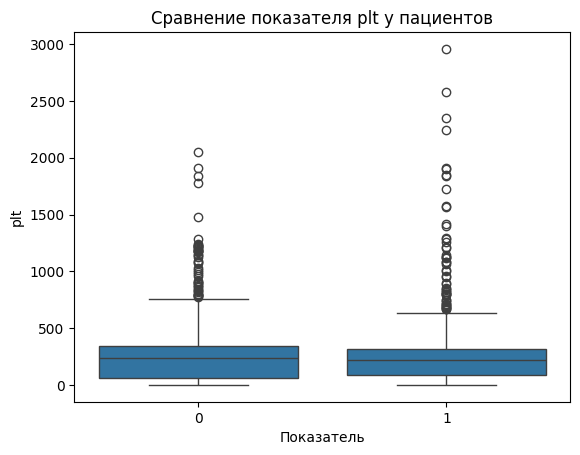

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mpv внутри
 представителей разного пола


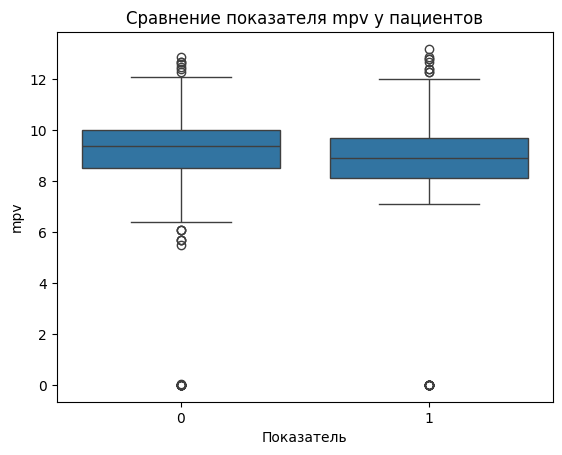

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя pdw внутри
 представителей разного пола


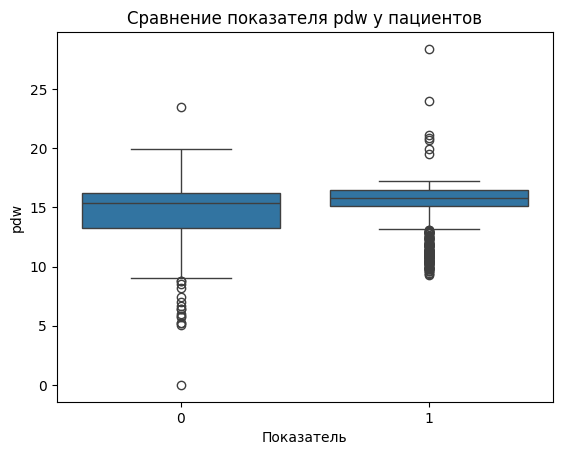

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя plcr внутри
 представителей разного пола


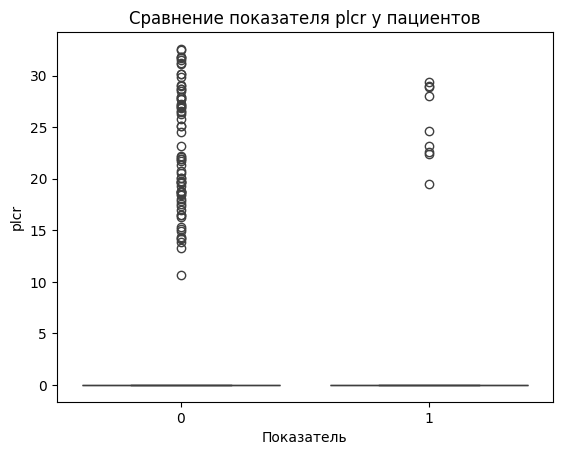

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя soe внутри
 представителей разного пола


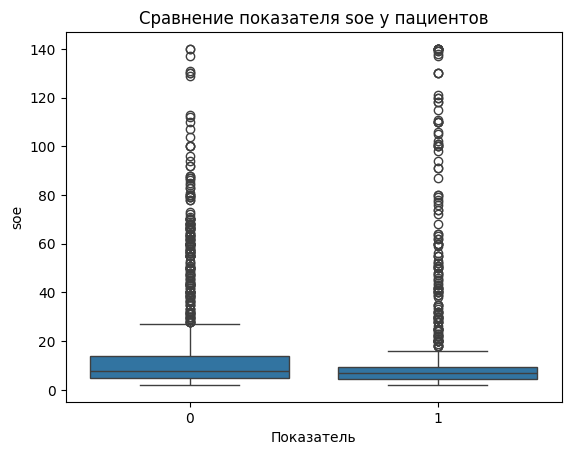

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя myelo внутри
 представителей разного пола


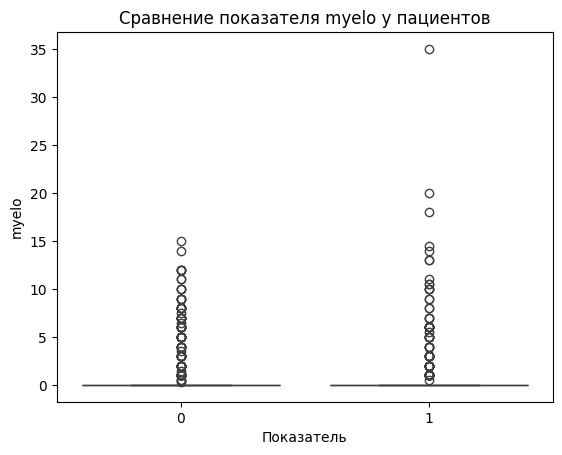

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя yunye внутри
 представителей разного пола


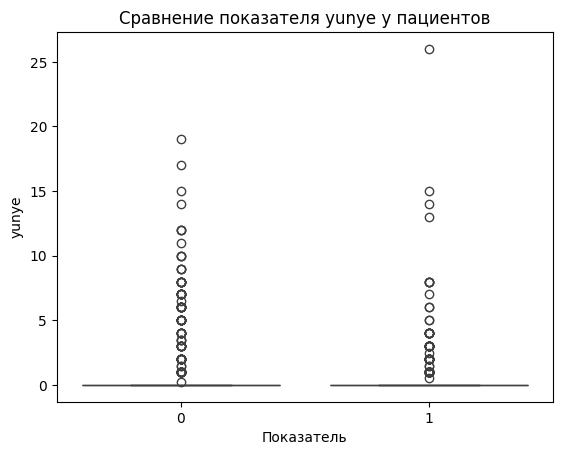

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя blasty внутри
 представителей разного пола


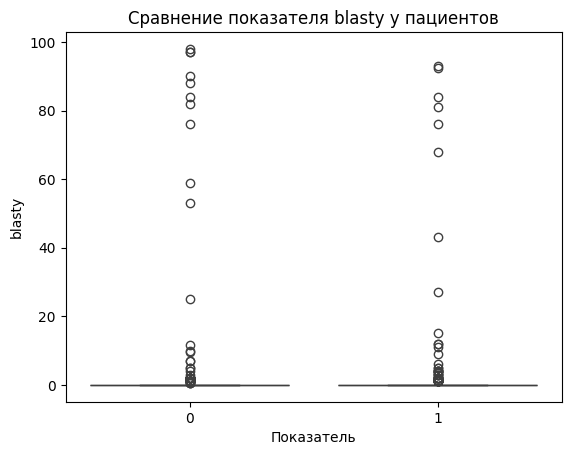

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя normobl_abs внутри
 представителей разного пола


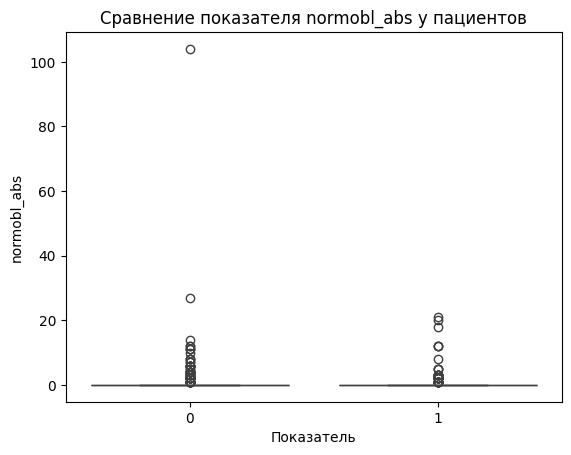

----------------------------------------------------------------------------------------------------


In [26]:
for col in num_col:
  print(f'Сравнение распределения показателя {col} внутри\n представителей разного пола')
  target_sigh(df, 'gender', col)
  print('-'*100)

##Корреляционный анализ

In [27]:
#подготовка данных для корреляции
#в связи с большим количеством данных и разбросом данных, не расчитать ранги
df_cleaned = df.drop('study_ID', axis=1)
df_cleaned = df_cleaned.fillna(df_cleaned.median())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

In [28]:
# QR-разложение для определения ранга корреляции
Q, R = np.linalg.qr(scaled_data)
qr_rank = np.sum(np.abs(R.diagonal()) > 1e-10)

print(f'QR-разложение (количество линейно независимых столбцов): {qr_rank}')
print(f'Количество столбцов: {scaled_data.shape[1]}')

QR-разложение (количество линейно независимых столбцов): 38
Количество столбцов: 38


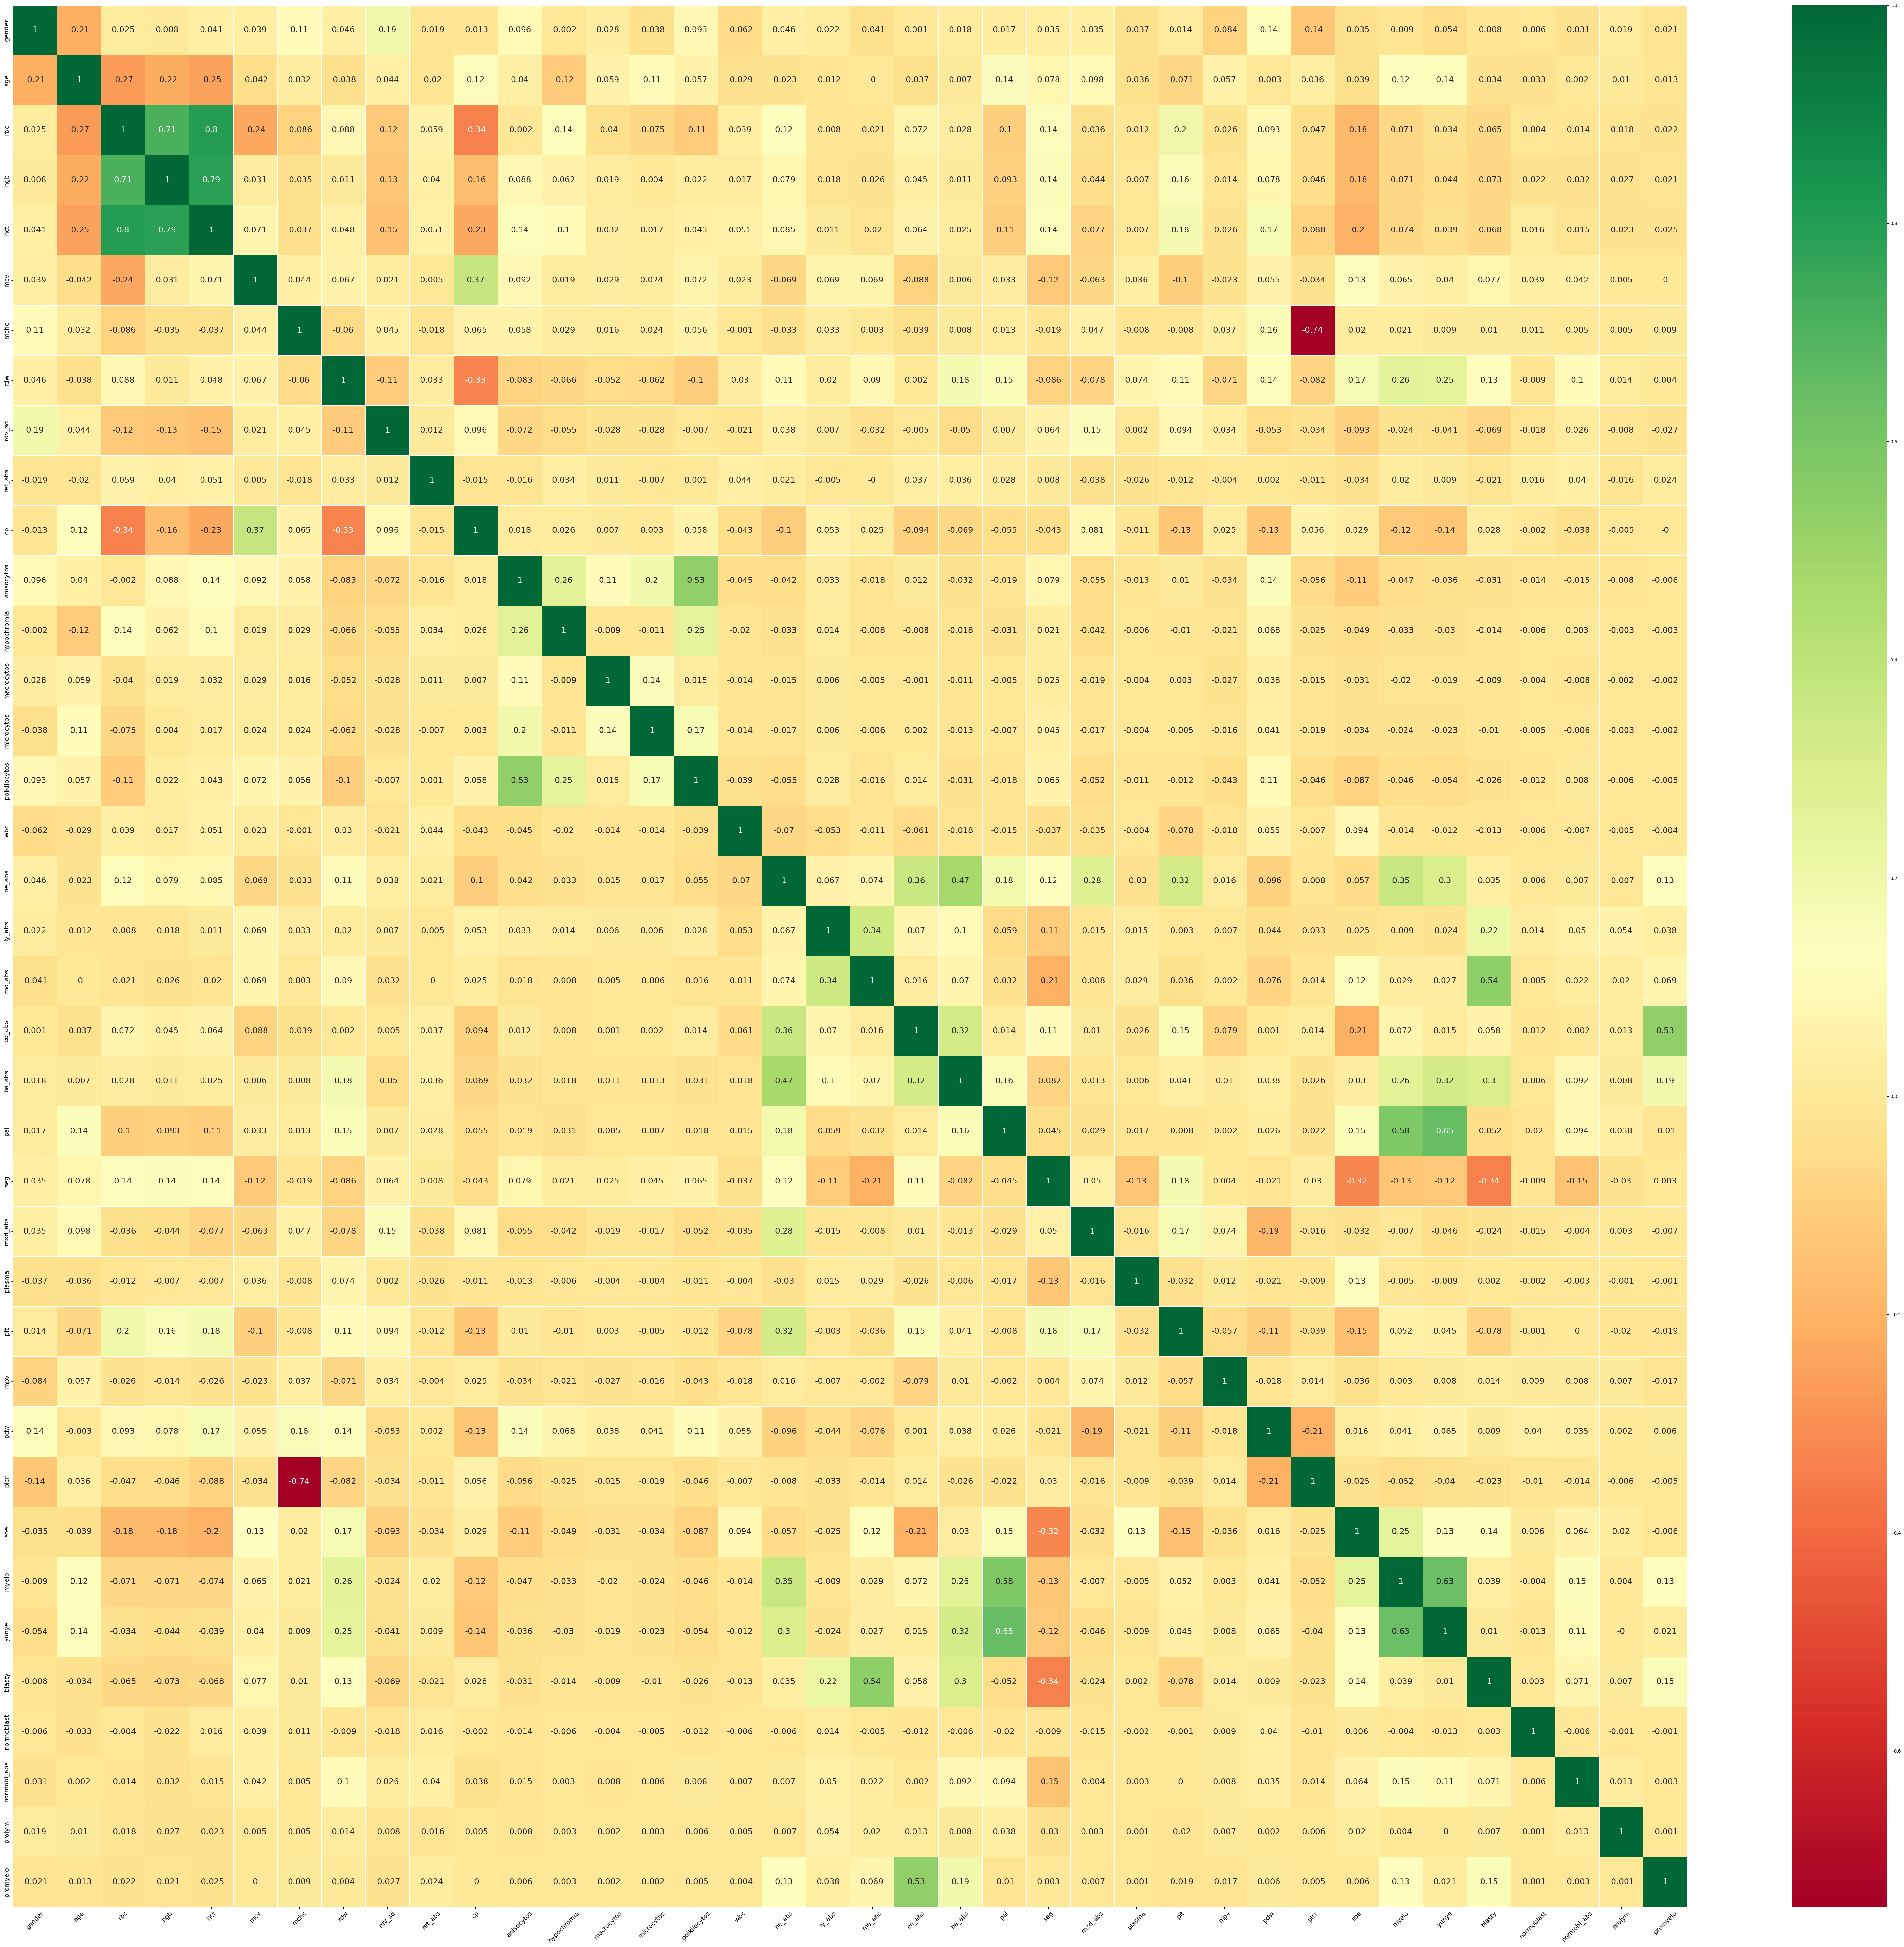

In [29]:
corr_matrix_df = round(df_cleaned.corr(), 3)

fig, ax = plt.subplots(figsize=(65, 60))
sns.heatmap(
    corr_matrix_df,
    annot=True,
    cmap='RdYlGn',
    annot_kws={"fontsize": 18},
    xticklabels=corr_matrix_df.columns,
    yticklabels=corr_matrix_df.index,
    linewidths=.5
)
ax.tick_params(axis="x", labelrotation=45, labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.tight_layout()
plt.show()

In [30]:
#выведем пары с корреляцией выше 0.5
threshold = 0.5

high_correlations = (
    corr_matrix_df
    .stack()
    .reset_index()
    .rename(columns={0:'Корреляция'})
    .query('level_0 != level_1')
    .query(f'abs(Корреляция) >= {threshold}')
)

result = high_correlations.sort_values(by='Корреляция', ascending=False)[['level_0', 'level_1', 'Корреляция']]
display(result)
print(f'Количество пар с корреляцией выше 0.5 {len(result)} штук')

,level_0,level_1,Корреляция
80,rbc,hct,0.801
154,hct,rbc,0.801
155,hct,hgb,0.785
118,hgb,hct,0.785
116,hgb,rbc,0.714
79,rbc,hgb,0.714
1238,yunye,pal,0.647
868,pal,yunye,0.647
1210,myelo,yunye,0.634
1247,yunye,myelo,0.634


Количество пар с корреляцией выше 0.5 20 штук


In [31]:
print('Код не упал!')

Код не упал!


##Написание словаря для разметки данных !ХЭЛПЬ!

In [32]:
#Словарь норм для Hb (г/л) и RBC (×10¹²/л) по полу и возрасту
norms = {
    'HGB': {
        'M': {'child': (110, 140), 'adult': (130, 160), 'old': (120, 150)},
        # мужчины: дети (1-12 лет), взрослые (13-59), пожилые (60+)
        'F': {'child': (110, 140), 'adult': (120, 150), 'old': (110, 140)}
        # женщины
    },
    'RBC': {
        'M': {'child': (3.5, 5.0), 'adult': (4.0, 5.5), 'old': (3.5, 5.0)},
        'F': {'child': (3.5, 5.0), 'adult': (3.8, 5.2), 'old': (3.5, 5.0)}
    },
    'WBC': (4.0, 9.0),  # общий для всех (×10⁹/л)
    'PLT': (150, 400),   # тромбоциты (×10⁹/л)
    'EOS': (0, 5),       # эозинофилы (%)
    'ESR': {'M': (2, 10), 'F': (2, 15)},  # СОЭ (мм/ч)
    'Blasts': (0, 0)     # бласты в норме отсутствуют
}


In [33]:
df.head(2)

,study_ID,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo
0,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,0,87,2.21,84.0,26.3,119.1,320.0,21.300000,52.144544,36.245919,1.140000,0.0,0.0,0.0,0.0,0.0,10.0,6.500000,1.300000,1.500000,0.200000,0.000000,3.000000,67.000000,0.294582,0.0,100.000000,7.579015,16.438954,0.0,12.000000,1.0,2.0,0.0,0.0,0.0,0.0,0.0
1,05deb1af-cf40-11e9-80ba-901b0e633689_result_1803,0,87,1.91,74.0,23.6,123.8,315.0,12.280473,41.106126,33.459317,0.903516,0.0,0.0,0.0,0.0,0.0,9.1,5.267876,4.590942,0.514909,0.416559,0.037165,4.772653,59.783114,0.508563,0.0,219.848188,7.908197,16.905172,0.0,3.174857,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
#функция проверяет соответсвие нормам
def process_entire_row(row, column_names, norms):
    # Преобразуем строку в словарь
    data = dict(zip(column_names, row))

    # Сбор результатов проверки
    results = {}

    # Определим пол и возраст
    gender = data['gender']
    age = data['age']

    # Проходим по каждому столбцу
    for i, col_name in enumerate(column_names):
        if col_name.lower() in ['study_id', 'gender', 'age']:
            continue

        # Преобразуем значение в число
        value = float(data[col_name])

        # Получаем нормативы для текущего параметра
        norm = norms.get(col_name.upper(), {})

        # Если параметр не описан в нормах, помечаем как неприменимый
        if not norm:
            results[col_name] = 'Параметр не описан в нормах'
            continue

        # Определяем границы нормы
        if isinstance(norm, tuple):
            lower_bound, upper_bound = norm
        else:
            # Определяем группу по полу и возрасту
            if gender == '0':
                gender_group = 'M'
            else:
                gender_group = 'F'

            # Устанавливаем группу по возрасту
            if age <= 12:
                group = 'child'
            elif age >= 60:
                group = 'old'
            else:
                group = 'adult'

            # Получаем границы нормы для указанной половой и возрастной группы
            lower_bound, upper_bound = norm[gender_group][group]

        # Оцениваем соответствие норме
        if value < lower_bound:
            results[col_name] = 'Понижено'
        elif value > upper_bound:
            results[col_name] = 'Повышено'
        else:
            results[col_name] = 'Норма'

    return results

In [35]:
process_entire_row(df.iloc[0], df.columns, norms)

{'rbc': 'Понижено',
 'hgb': 'Понижено',
 'hct': 'Параметр не описан в нормах',
 'mcv': 'Параметр не описан в нормах',
 'mchc': 'Параметр не описан в нормах',
 'rdw': 'Параметр не описан в нормах',
 'rdv_sd': 'Параметр не описан в нормах',
 'ret_abs': 'Параметр не описан в нормах',
 'cp': 'Параметр не описан в нормах',
 'anisocytos': 'Параметр не описан в нормах',
 'hypochromia': 'Параметр не описан в нормах',
 'macrocytos': 'Параметр не описан в нормах',
 'microcytos': 'Параметр не описан в нормах',
 'poikilocytos': 'Параметр не описан в нормах',
 'wbc': 'Повышено',
 'ne_abs': 'Параметр не описан в нормах',
 'ly_abs': 'Параметр не описан в нормах',
 'mo_abs': 'Параметр не описан в нормах',
 'eo_abs': 'Параметр не описан в нормах',
 'ba_abs': 'Параметр не описан в нормах',
 'pal': 'Параметр не описан в нормах',
 'seg': 'Параметр не описан в нормах',
 'mxd_abs': 'Параметр не описан в нормах',
 'plasma': 'Параметр не описан в нормах',
 'plt': 'Понижено',
 'mpv': 'Параметр не описан в норм

In [36]:
conditions = {
    0: lambda result: all(status == 'Норма' for status in result.values()),  # Все параметры в норме
    1: lambda result: result.get('HGB', '') == 'Понижено' or result.get('RBC', '') == 'Понижено',  # Понижение хотя бы одного главного показателя
    2: lambda result: any(status == 'Повышено' for status in result.values()),  # Повышение какого-либо показателя
    3: lambda _: True  # Любое другое условие
}

In [37]:
def calculate_class(row, norms, conditions):

    # Преобразуем строку в словарь
    data = row.to_dict()

    # Пол и возраст
    gender = data['gender']  # Пусть 0="Мужской", 1="Женский"
    age = data['age']  # Преобразование возраста в целое число

    # Проверяем все колонки кроме service-колонок
    results = {}
    for col_name in row.index:
        if col_name.lower() in ['study_id', 'gender', 'age']:
            continue

        # Преобразуем значение в число
        value = float(data[col_name])

        # Получаем нормативы для текущего параметра
        norm = norms.get(col_name.upper(), {})

        # Если параметр не описан в нормах, помечаем как неприменимый
        if not norm:
            results[col_name] = 'Параметр не описан в нормах'
            continue

        # Определяем границы нормы
        if isinstance(norm, tuple):
            lower_bound, upper_bound = norm
        else:
            # Определяем группу по полу и возрасту
            gender_group = 'M' if gender == '0' else 'F'
            if age <= 12:
                group = 'child'
            elif age >= 60:
                group = 'old'
            else:
                group = 'adult'

            # Граница нормы для данной группы
            lower_bound, upper_bound = norm[gender_group][group]

        # Оцениваем соответствие норме
        if value < lower_bound:
            results[col_name] = 'Понижено'
        elif value > upper_bound:
            results[col_name] = 'Повышено'
        else:
            results[col_name] = 'Норма'

    # Определяем итоговый класс
    final_class = None
    for cls, condition in sorted(conditions.items()):
        if condition(results):
            final_class = cls
            break

    return final_class

In [38]:
df.columns

Index(['study_ID', 'gender', 'age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw',
       'rdv_sd', 'ret_abs', 'cp', 'anisocytos', 'hypochromia', 'macrocytos',
       'microcytos', 'poikilocytos', 'wbc', 'ne_abs', 'ly_abs', 'mo_abs',
       'eo_abs', 'ba_abs', 'pal', 'seg', 'mxd_abs', 'plasma', 'plt', 'mpv',
       'pdw', 'plcr', 'soe', 'myelo', 'yunye', 'blasty', 'normoblast',
       'normobl_abs', 'prolym', 'promyelo'],
      dtype='object')

In [39]:
test_func_data = df[['study_ID', 'gender', 'age', 'rbc', 'hgb']]

In [40]:
test_func_data['class'] = test_func_data.apply(lambda row: calculate_class(row, norms, conditions),
                                               axis=1)

/tmp/ipython-input-40-1233388196.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_func_data['class'] = test_func_data.apply(lambda row: calculate_class(row, norms, conditions),


In [41]:
test_func_data.head(2)

,study_ID,gender,age,rbc,hgb,class
0,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,0,87,2.21,84.0,3
1,05deb1af-cf40-11e9-80ba-901b0e633689_result_1803,0,87,1.91,74.0,3


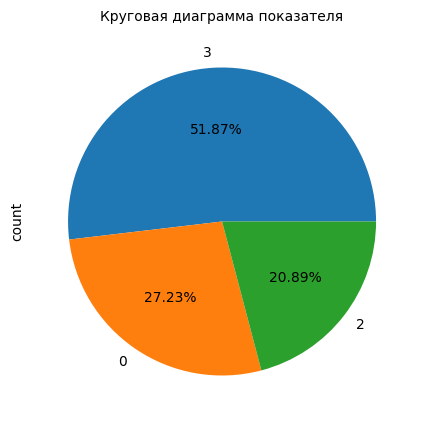

In [42]:
analisys_cat_pie(test_func_data['class'])

In [43]:
print('Код не упал!')

Код не упал!
